In [26]:
using IRQIV
import CSV
using DataFrames
import PyPlot as plt
import Statistics, NaNStatistics
import Geodesy
import Pkg
import Dates
using TimeZones
import LaTeXStrings
plt.pygui(true) # sets plots to popup instead of inline

# Global camera parameters
fl = 1214.2857142857144 # In pixels - from Seth
include(raw"/Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/examples/CameraCalibrationHelpers.jl")
# include(raw"/Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/src/SpatialInterpolation.jl")
Camera = IRQIV.FLIR_SC8303_17mm
ι = IRQIV.IntrinsicCalibrationParameters(Camera)
Img_dims = [784, 1344] # Image dims: 784 x 1344

# Use Pkg.develop(path="/Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl") to update IRQIV.jl (after pulling from repo)

Threads.nthreads() # Can run in 8 threads

8

In [27]:
# import Pkg
# Pkg.instantiate()
# Pkg.develop(path="/Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl")

In [28]:
# Import GCP data
DH_survey = CSV.read("/Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/2023/CornellDuckHarbor2023.csv", DataFrames.DataFrame)
GCPs_8_1_SC = DH_survey[16:64,:] # DataFrames makes first row headers

# camlla_SC = GCPs_8_1_SC[37,7:9]
camutm_SC = GCPs_8_1_SC[37,3:5]
# camlla_SC[3] += 2 # Guess elevation of 2m over camera spot
camutm_SC[3] += 2
# camutm_SC = Geodesy.UTMZ(
#     Geodesy.LLA(camlla_SC[2], camlla_SC[1], camlla_SC[3]), Geodesy.wgs84
# )

5.04

In [29]:
fmt = Dates.dateformat"yyyy-mm-dd HH:MM:SS.s zzz"
DH_survey_times = ZonedDateTime.(
    replace.(DH_survey."Averaging end", "UTC" => ""),
    fmt)
DH_survey_ET = astimezone.(DH_survey_times, tz"America/New_York")
inds_8_1 = Dates.Date.(DH_survey_ET) .== Dates.Date(2023, 8, 1)
DH_survey_8_1 = DH_survey[inds_8_1,:]


Row,Name,Code,Easting,Northing,Elevation,Description,Longitude,Latitude,Ellipsoidal height,Easting RMS,Northing RMS,Elevation RMS,Lateral RMS,Antenna height,Antenna height units,Solution status,Averaging start,Averaging end,Samples,PDOP,Base easting,Base northing,Base elevation,Base longitude,Base latitude,Base ellipsoidal height,Baseline,CS name
,String31,Missing,Float64,Float64,Float64,String?,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,String1,String3,String31,String31,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,String
1,NC_stakes_bot_01,missing,4.10798e5,4.64445e6,1.663,north channel 20230731,-70.0762,41.947,-26.093,0.01,0.01,0.014,0.014,1.474,m,FIX,2023-08-01 15:36:27.0 UTC-04:00,2023-08-01 15:36:30.0 UTC-04:00,16,1.9,4.10948e5,4.64434e6,4.069,-70.0744,41.946,-23.687,187.793,NAD83(2011) / UTM zone 19N + us_noaa_g2012bu0.tif
2,NC_stakes_bot_02,missing,4.10797e5,4.64445e6,1.671,north channel 20230731,-70.0762,41.947,-26.085,0.01,0.01,0.015,0.014,1.474,m,FIX,2023-08-01 15:36:44.4 UTC-04:00,2023-08-01 15:36:47.4 UTC-04:00,16,1.9,4.10948e5,4.64434e6,4.069,-70.0744,41.946,-23.687,187.489,NAD83(2011) / UTM zone 19N + us_noaa_g2012bu0.tif
3,NC_stakes_bot_03,missing,4.10797e5,4.64445e6,1.634,north channel 20230731,-70.0762,41.9469,-26.122,0.01,0.011,0.014,0.015,1.474,m,FIX,2023-08-01 15:37:01.0 UTC-04:00,2023-08-01 15:37:04.0 UTC-04:00,16,1.9,4.10948e5,4.64434e6,4.069,-70.0744,41.946,-23.687,187.323,NAD83(2011) / UTM zone 19N + us_noaa_g2012bu0.tif
4,NC_stakes_bot_04,missing,410796.0,4.64444e6,1.612,north channel 20230731,-70.0762,41.9469,-26.144,0.01,0.01,0.015,0.014,1.474,m,FIX,2023-08-01 15:37:24.2 UTC-04:00,2023-08-01 15:37:27.2 UTC-04:00,16,1.9,4.10948e5,4.64434e6,4.069,-70.0744,41.946,-23.687,187.029,NAD83(2011) / UTM zone 19N + us_noaa_g2012bu0.tif
5,NC_stakes_bot_05,missing,4.10795e5,4.64444e6,1.587,north channel 20230731,-70.0762,41.9469,-26.169,0.01,0.01,0.017,0.014,1.474,m,FIX,2023-08-01 15:37:54.6 UTC-04:00,2023-08-01 15:37:57.6 UTC-04:00,16,1.9,4.10948e5,4.64434e6,4.069,-70.0744,41.946,-23.687,186.889,NAD83(2011) / UTM zone 19N + us_noaa_g2012bu0.tif
6,NC_stakes_bot_06,missing,4.10795e5,4.64444e6,1.564,north channel 20230731,-70.0762,41.9469,-26.192,0.011,0.01,0.019,0.015,1.474,m,FIX,2023-08-01 15:38:12.0 UTC-04:00,2023-08-01 15:38:15.0 UTC-04:00,16,1.9,4.10948e5,4.64434e6,4.069,-70.0744,41.946,-23.687,186.616,NAD83(2011) / UTM zone 19N + us_noaa_g2012bu0.tif
7,NC_stakes_bot_07,missing,4.10794e5,4.64444e6,1.685,north channel 20230731,-70.0762,41.9469,-26.071,0.011,0.01,0.017,0.015,1.474,m,FIX,2023-08-01 15:38:29.0 UTC-04:00,2023-08-01 15:38:32.0 UTC-04:00,16,1.9,4.10948e5,4.64434e6,4.069,-70.0744,41.946,-23.687,186.314,NAD83(2011) / UTM zone 19N + us_noaa_g2012bu0.tif
8,NC_stakes_bot_08,missing,4.10796e5,4.64445e6,1.682,north channel 20230731,-70.0762,41.947,-26.074,0.01,0.01,0.015,0.015,1.474,m,FIX,2023-08-01 15:38:51.6 UTC-04:00,2023-08-01 15:38:54.6 UTC-04:00,16,2.0,4.10948e5,4.64434e6,4.069,-70.0744,41.946,-23.687,188.828,NAD83(2011) / UTM zone 19N + us_noaa_g2012bu0.tif
9,NC_stakes_bot_09,missing,4.10796e5,4.64445e6,1.655,north channel 20230731,-70.0762,41.947,-26.101,0.01,0.01,0.017,0.014,1.474,m,FIX,2023-08-01 15:39:06.0 UTC-04:00,2023-08-01 15:39:09.0 UTC-04:00,16,2.0,4.10948e5,4.64434e6,4.069,-70.0744,41.946,-23.687,188.455,NAD83(2011) / UTM zone 19N + us_noaa_g2012bu0.tif


In [30]:
SC_bots_uv_8_1 = [854 564 # SC1 bot
                751 108 # SC2 bot 
                426 64 # SC3 bot
                342 57 # SC4 bot
                287 51 # SC6 bot
                259 141 # SC8 bot
                242 132 # SC9 bot
                228 131 # SC10 bot
                230 226 # SC11 bot
                236 381 # SC12 bot
                344 639 # SC13 bot
                255 593 # NC1 bot
                266 656 # NC7 bot 
]

SC_tops_uv_8_1 = [622 602 # SC1 top
                550 114 # SC2 top
                318 63 # SC3 top
                273 61 # SC4 top
                236 53 # SC6 top
                230 63 # SC7 top
                228 141 # SC8 top
                218 133 # SC9 top
                205 131 # SC10 top
                217 227 # SC11 top
                218 381 # SC12 top
                #229 512 # Stump
                301 651 # SC13 top
                239 594 # NC1 top
                253 659 # NC7 top
]

SC_uv_8_1 = [SC_bots_uv_8_1
    SC_tops_uv_8_1]

27×2 Matrix{Int64}:
 854  564
 751  108
 426   64
 342   57
 287   51
 259  141
 242  132
 228  131
 230  226
 236  381
   ⋮  
 230   63
 228  141
 218  133
 205  131
 217  227
 218  381
 301  651
 239  594
 253  659

In [31]:
SC_bots_xyz_8_1 = GCPs_8_1_SC[25:36,[1,3,4,5]] # Name, Easting, Northing, Elevation
deleteat!(SC_bots_xyz_8_1, 6)
SC_bots_xyz_8_1 = [SC_bots_xyz_8_1
                GCPs_8_1_SC[1:7,[1,3,4,5]]]
deleteat!(SC_bots_xyz_8_1, (13:17))

SC_tops_xyz_8_1 = GCPs_8_1_SC[38:49,[1,3,4,5]] # "
SC_tops_xyz_8_1 = [SC_tops_xyz_8_1
                GCPs_8_1_SC[13:19,[1,3,4,5]]]
deleteat!(SC_tops_xyz_8_1, (14:18))

SC_xyz_8_1_utm = Matrix([SC_bots_xyz_8_1[:,2:4]
                SC_tops_xyz_8_1[:,2:4]])

27×3 Matrix{Float64}:
      4.10794e5  4.64438e6  2.069
      4.10797e5  4.64438e6  2.017
      4.108e5    4.64438e6  1.912
      4.10802e5  4.64439e6  1.816
      4.10805e5  4.64439e6  1.791
      4.10807e5  4.6444e6   1.679
      4.1081e5   4.64441e6  1.722
      4.10812e5  4.64441e6  1.733
      4.10811e5  4.64442e6  1.741
      4.10807e5  4.64443e6  1.819
      ⋮                     
      4.10807e5  4.6444e6   2.696
      4.10808e5  4.6444e6   2.731
      4.1081e5   4.64441e6  2.763
      4.10812e5  4.64441e6  2.771
 410811.0        4.64442e6  2.789
      4.10807e5  4.64443e6  2.864
      4.10795e5  4.6444e6   2.784
      4.10798e5  4.64445e6  2.718
      4.10794e5  4.64444e6  2.655

┌ Warning: Too few BHPHeaders to calculate fps!
└ @ IRQIV.FLIRATSFiles /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/src/FLIRATSFiles.jl:415
┌ Info: (410794.484, 410794.0570763494)
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/examples/CameraCalibrationHelpers.jl:68
┌ Info: (410796.502, 410796.72744481906)
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/examples/CameraCalibrationHelpers.jl:68
┌ Info: (410799.794, 410801.4994140608)
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/examples/CameraCalibrationHelpers.jl:68
┌ Info: (410802.309, 410807.2875035188)
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/examples/CameraCalibrationHelpers.jl:68
┌ Info: (410805.373, 410819.7751093513)
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/examples/CameraCalibrationHelpers.jl:68
┌ Info: (410807.425, 410832.1393202742)
└ @ Main /Users/e

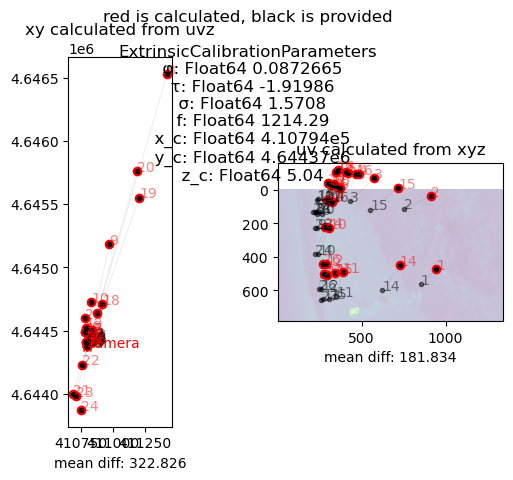

In [32]:
# Camera location calibration setup - south channel

# All converge for 8/1
azimuth_SC_g = deg2rad(5) # Guess from google maps
tilt_SC_g = deg2rad(-110) # From looking straight up?
roll_SC_g = deg2rad(90)

# χinitial_SC = ExtrinsicCalibrationParameters(azimuth_SC_g, tilt_SC_g, roll_SC_g, fl, camutm_SC.x, camutm_SC.y, camutm_SC.z)
χinitial_SC = ExtrinsicCalibrationParameters(azimuth_SC_g, tilt_SC_g, roll_SC_g, fl, camutm_SC.Easting, camutm_SC.Northing, camutm_SC.Elevation)

TrueGCPuv_SC_8_1 = hcat(RemoveRadialDistortion(SC_uv_8_1[:,1], SC_uv_8_1[:,2], Camera)...)

plt.close("all")
GCP_path_SC_8_1 = ("/Volumes/ETH_4TB/DH_IR/Rec-HRE_2023_-003701-__TIME__.ats")
GCP_image_SC_8_1 = LoadATSImageSequence(GCP_path_SC_8_1, 1, 2023)
GraphicallyExploreInitialCalibrationGuess(TrueGCPuv_SC_8_1, SC_xyz_8_1_utm, χinitial_SC, ι, GCP_image_SC_8_1[1])
plt.gcf()


Finished extrinsic calibration:, 8 iterations, max(|ε|)=4e-10, rms(ε₁-ε₀)=7e-11
ExtrinsicCalibrationParameters
  φ: Float64 0.08726646259971647
  τ: Float64 -1.9198621771937625
  σ: Float64 1.5707963267948966
  f: Float64 1214.2857142857144
  x_c: Float64 410794.429
  y_c: Float64 4.64437235e6
  z_c: Float64 5.04
dump(χinitial_SC) = nothing
ExtrinsicCalibrationParameters
  φ: Float64 0.15869781643954087
  τ: Float64 -1.972435537585546
  σ: Float64 1.7057036423637064
  f: Float64 1155.4743546371924
  x_c: Float64 410794.64867768675
  y_c: Float64 4.644372713478437e6
  z_c: Float64 4.551520618100407
dump(χcalculated_SC_8_1) = nothing
φ diff (degrees) -  -4.092715099927545
τ diff (degrees) -  3.012231665269443
σ diff (degrees) -  -7.729619807532348
f diff -  58.81135964852206
x_c diff (meters) -  -0.21967768674949184
y_c diff (meters) -  -0.3634784370660782
z_c diff (meters) -  0.4884793818995927


┌ Info: Initial guess, χinitial:
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/CACO_git/CACO_23_jl/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X10sZmlsZQ==.jl:11
┌ Info: Calibrated values, χcalculated:
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/CACO_git/CACO_23_jl/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X10sZmlsZQ==.jl:14
┌ Info: Difference between calibrated value and initial guess:
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/CACO_git/CACO_23_jl/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X10sZmlsZQ==.jl:18
┌ Info: (410794.484, 410794.51926754025)
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/examples/CameraCalibrationHelpers.jl:68
┌ Info: (410796.502, 410796.55485607334)
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/examples/CameraCalibrationHelpers.jl:68
┌ Info: (410799.794, 410799.76047922194)
└ @ Main /Users/evanheberl

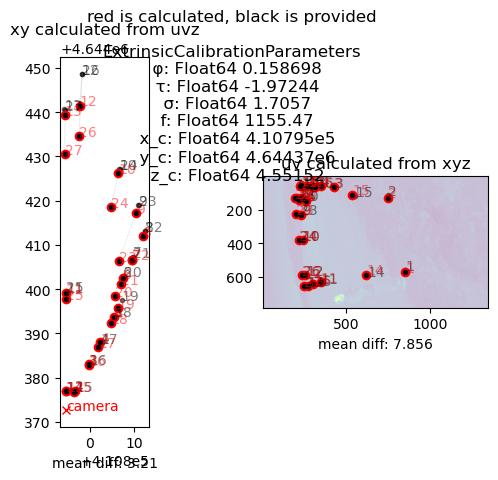

In [33]:
# Camera location calibration - south channel

χcalculated_SC_8_1 = ExtrinsicCalibration(
    TrueGCPuv_SC_8_1,
    SC_xyz_8_1_utm,
    χinitial_SC,
    ι,
    MaxIterations = 50,
    PrintoutStats=true)

@info "Initial guess, χinitial:"
@show dump(χinitial_SC)
# 
@info "Calibrated values, χcalculated:"
@show dump(χcalculated_SC_8_1)
# 
# Describe how much the calibration changed each parameter:
@info "Difference between calibrated value and initial guess:"
for (i,x) in enumerate(fieldnames(typeof(χcalculated_SC_8_1)))
    if i <= 3
        println("$x diff (degrees) -  $(rad2deg(getfield(χinitial_SC, x) - getfield(χcalculated_SC_8_1, x)))")
    elseif i == 4
        println("$x diff -  $(getfield(χinitial_SC, x) - getfield(χcalculated_SC_8_1, x))")
    else
        println("$x diff (meters) -  $(getfield(χinitial_SC, x) - getfield(χcalculated_SC_8_1, x))")
    end
end

dlt = IRQIV.DLT(χcalculated_SC_8_1, FLIR_SC8303_17mm)


plt.close("all")
GraphicallyExploreInitialCalibrationGuess(TrueGCPuv_SC_8_1, SC_xyz_8_1_utm, χcalculated_SC_8_1, ι, GCP_image_SC_8_1[1])
plt.gcf()

In [34]:
SC4_bot_z = SC_bots_xyz_8_1[4,4]
SC6_bot_z = SC_bots_xyz_8_1[5,4]
SC8_bot_z = SC_bots_xyz_8_1[6,4]
SC9_bot_z = SC_bots_xyz_8_1[7,4]
SC10_bot_z = SC_bots_xyz_8_1[8,4]
SC11_bot_z = SC_bots_xyz_8_1[9,4]

# SC4_bot_z - χcalculated_SC_8_1.z_c
# SC6_bot_z - χcalculated_SC_8_1.z_c
# SC_bots_xyz_8_1
# SC 4 bottom is WSE, SC12 is on other side of channel and w/in 3cm vertically
SC_4_uv = SC_bots_uv_8_1[4,:]
SC_6_uv = SC_bots_uv_8_1[5,:]
SC_9_uv = SC_bots_uv_8_1[7,:]
SC_10_uv = SC_bots_uv_8_1[8,:]
SC_11_uv = SC_bots_uv_8_1[9,:]
SC_12_uv = SC_bots_uv_8_1[10,:]
SC6_bot_z-SC11_bot_z


0.04999999999999982

In [35]:
# File numbers & water levels:
# 3714 - SC8 bot (people in frame at beginning): lowest elevation, across from nothing, no waves in channel yet
# 3717 - SC6 bot: closer in elev. to SC12 than closer SC11, SC9 looks like other side but is much lower
# 3723 - SC4 bot: w/in 3cm of SC12 across channel
# 3733 (last file) b/w SC3 bot & SC4 bot
# Find range of original line SC4-SC12 that is edge of channel at SC6 elevation, redistribute STIV lines, 2-point curve

In [36]:
# Time series of rectified image

interpolated_grid_spacing=.1
RectParams = IRQIV.ImageRectification.calculate_image_rectification(Camera, χcalculated_SC_8_1, # May have to switch git forks?
SC4_bot_z; 
interpolated_grid_spacing,
# y_limits = (4644380, 4644390))
# y_limits = (camutm_SC.y+10, camutm_SC.y+20))
# y_limits = (camutm_SC.y, maximum(SC_xyz_8_1_utm[:,2])))
u_limits = (290, 900))

# Select IR image file:
WSE = SC4_bot_z

DH_survey_WSE_diff = DH_survey_8_1.Elevation .- WSE
DH_survey_u, DH_survey_v = IRQIV.xyz2uv(DH_survey_8_1.Easting, 
    DH_survey_8_1.Northing, DH_survey_8_1.Elevation, dlt)

FLIR_filename = raw"/Volumes/ETH_4TB/DH_IR/Rec-HRE_2023_-003723-__TIME__.ats"
# FLIR_filename = raw"/Volumes/ETH_4TB/DH_IR/Rec-HRE_2023_-003717-__TIME__.ats"
# FLIR_filename = raw"/Volumes/ETH_4TB/DH_IR/Rec-HRE_2023_-003714-__TIME__.ats"
# FLIR_filename = raw"/Volumes/ETH_4TB/DH_IR/Rec-HRE_2023_-003749-__TIME__.ats"

# Load IR images (from Sutter Slough):
nfiles = 201 # approx. 10 sec
file_step = 1
IRimages = LoadATSImageSequence(FLIR_filename, (file_step-1)*nfiles+1:file_step*nfiles, 2023)
far_field_exclude = 375#350 # How many rows to remove from top of rectified image

# Rectify a single image
# plt.close("all")
# fig = plt.figure()#(figsize=(9, 9))
# for i in 1:length(IRimages)
#     # rectified_image = RectParams(IRimages[i])[far_field_exclude:end-50,:]
#     # rectified_image = reverse(permutedims(IRimages[:,:,i], (2, 1)), dims=2)[200:400,:]
#     #
#     ax = plt.gca()
#     ax.cla() # Clear figure

#     # ax.scatter(DH_survey_8_1.Easting, DH_survey_8_1.Northing, c = DH_survey_WSE_diff, zorder = 2)
#     plt.scatter(DH_survey_u, DH_survey_v, c = DH_survey_WSE_diff, cmap="RdYlGn", zorder = 2)
#     plt.pause(.1)
#     # plt.xlabel("UTM z19N easting (m)")
#     # plt.ylabel("UTM z19N northing (m)")
#     plt.scatter(SC_6_uv[1], SC_6_uv[2], color = "white", zorder = 3)
#     ax.imshow(IRimages[i], zorder = 1)
#     # ax.axhline(STIV_row+far_field_exclude, color="red", linestyle="--", linewidth=2) # Changes figure dimensions, imshow disappears
#     # function annotate_pixel_coordinates(event) # Trying to get pixel coordinates in imshow, not working
#     #     x, y = round(event.x), round(event.y)
#     #     ax.annotate("($x, $y)", xy=(event.x, event.y), xytext=(x + 1, y + 1), color="white", fontsize=8)
#     #     fig.canvas.draw_idle()  # Force redraw to update the annotation
#     # end
#     # connect(plt.gcf(), "button_press_event", annotate_pixel_coordinates)


#     # Update rectified image to last image in data set, plot this as well:
#     # rectified_image = RectParams(rectified_image, IRimages[end])
#     # ax[2].imshow(rectified_image;extent=RectParams.extent)
#     ax.set_title("Datetime: $(ats_ts(IRimages)[i])")
#     ###############################################################################
#     plt.show()
# end
# plt.close("all")
# fig, ax = plt.subplots()


# for i in 1:length(IRimages)
#     ax.cla()  # clear axes at start

#     # Scatter overlays
#     ax.scatter(DH_survey_u, DH_survey_v, c=DH_survey_WSE_diff, cmap="RdYlGn", zorder=2)
#     ax.scatter(SC_6_uv[1], SC_6_uv[2], color="white", zorder=3)
#     # ax.scatter(SC_12_uv[1], SC_12_uv[2], color="white", zorder=3)
#     ax.plot([SC_4_uv[1], SC_12_uv[1]], [SC_4_uv[2], SC_12_uv[2]], color = "white", zorder = 2)

#     # Plot rectified image
#     ax.imshow(IRimages[i], extent = (0, size(IRimages)[2], size(IRimages)[1], 0), zorder=1)

#     # Update title
#     ax.set_title("Datetime: $(ats_ts(IRimages)[i])")

#     plt.pause(0.1)  # short pause to update
# end

  0.004157 seconds (83.61 k allocations: 4.158 MiB)


375

In [37]:
# Extract FLIR metadata
FLIR_filename = raw"/Volumes/ETH_4TB/DH_IR/Rec-HRE_2023_-003723-__TIME__.ats"

FLIR_meta_summary = IRQIV.FLIRATSFiles.FindATSFileMetadata(FLIR_filename, ATSfps = NaN, ats_year = 2023)
lastframe = FLIR_meta_summary.EstimatedTotalFrames
_,FLIR_meta_full = IRQIV.FLIRATSFiles.LoadMultipleFrames(FLIR_meta_summary, collect(1:1:lastframe), ats_year=2023, ReadFrame=false)
FLIR_meta_time = TimeZones.ZonedDateTime(
    IRQIV.FLIRATSFiles.ParseBHPHeaderTimestamp(FLIR_meta_full, ats_year = 2023)[1], # First frame corresponds to file modeified time
    TimeZones.tz"America/New_York"
)

# Extract metadata from file using base functions
file_meta_time = TimeZones.ZonedDateTime(Dates.unix2datetime(stat(FLIR_filename).mtime), TimeZones.tz"UTC")
file_meta_time = TimeZones.astimezone(file_meta_time, TimeZones.tz"America/New_York")

# Calculate and correct for offset between two metadata times
meta_time_offset = FLIR_meta_time - file_meta_time
high_WL_ts = IRQIV.FLIRATSFiles.ParseBHPHeaderTimestamp(FLIR_meta_full, ats_year = 2023) .- meta_time_offset

3600-element Vector{DateTime}:
 2023-08-01T23:26:46
 2023-08-01T23:26:46.066
 2023-08-01T23:26:46.100
 2023-08-01T23:26:46.133
 2023-08-01T23:26:46.200
 2023-08-01T23:26:46.266
 2023-08-01T23:26:46.300
 2023-08-01T23:26:46.366
 2023-08-01T23:26:46.400
 2023-08-01T23:26:46.466
 ⋮
 2023-08-01T23:29:45.566
 2023-08-01T23:29:45.599
 2023-08-01T23:29:45.666
 2023-08-01T23:29:45.699
 2023-08-01T23:29:45.766
 2023-08-01T23:29:45.799
 2023-08-01T23:29:45.833
 2023-08-01T23:29:45.899
 2023-08-01T23:29:45.966

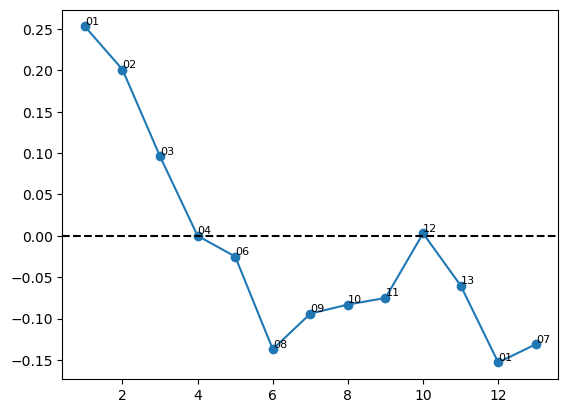

In [38]:
import StaticArrays, LinearAlgebra
import PyPlot as plt

# See how GCP location bathymetry matches up to measurements
"""
    project_gcps_to_transect(X, Y, Z, ref_start_xy, ref_end_xy; WSE, clamp_to_segment=true)

Project (x,y,z) points onto a transect defined by two endpoints in xy.
Returns:
- s      : along-transect distance (m) from ref_start_xy
- depth  : WSE - Z  (positive downward; flip if you prefer)
- L      : transect length (m)
"""
function project_gcps_to_transect(X, Y, Z, ref_start_xy, ref_end_xy; WSE, clamp_to_segment=true)
    p0 = StaticArrays.SVector(ref_start_xy...)
    p1 = StaticArrays.SVector(ref_end_xy...)
    t  = p1 - p0
    L  = LinearAlgebra.norm(t); @assert L > 0 "Transect has zero length"
    t̂  = t / L

    N = length(X)
    s     = Vector{Float64}(undef, N)
    depth = Vector{Float64}(undef, N)

    for i in 1:N
        p = @StaticArrays.SVector [X[i], Y[i]]
        r = p - p0
        s[i] = LinearAlgebra.dot(r, t̂)
        if clamp_to_segment
            s[i] = clamp(s[i], 0.0, L)
        end
        depth[i] = WSE - Z[i]   # change to Z[i]-WSE for positive-up
    end
    return s, depth, L
end

gcp_distances, gcp_depths, gcp_transect_length = project_gcps_to_transect(SC_bots_xyz_8_1[4:10,2], SC_bots_xyz_8_1[4:10,3], SC_bots_xyz_8_1[4:10,4],
    SC_bots_xyz_8_1[4,2:3], SC_bots_xyz_8_1[10,2:3]; WSE)

plt.figure()

yvals = SC_bots_xyz_8_1[:, 4] .- WSE  # your y-values
xvals = 1:length(yvals) 
labels = [last(string(SC_bots_xyz_8_1[i,1]), 2) for i in 1:length(yvals)]  # last 2 chars
plt.plot(xvals, yvals, "o-")
plt.axhline(0, color="k", linestyle="--")

# Add text labels near each point
for (x, y, lbl) in zip(xvals, yvals, labels)
    plt.text(x, y, lbl, fontsize=8, ha="left", va="bottom")
end

plt.gcf()



In [39]:
# Set up transect across overwash channel between GCPs @ WSE

function bresenham_line(x0, y0, x1, y1)
    pixels = []
    dx = abs(x1 - x0)
    dy = abs(y1 - y0)
    sx = x0 < x1 ? 1 : -1
    sy = y0 < y1 ? 1 : -1
    err = dx - dy

    while true
        push!(pixels, (x0, y0))
        if x0 == x1 && y0 == y1
            break
        end
        e2 = 2 * err
        if e2 > -dy
            err -= dy
            x0 += sx
        end
        if e2 < dx
            err += dx
            y0 += sy
        end
    end
    return pixels
end

transect_uv = bresenham_line(SC_4_uv[1], SC_4_uv[2], SC_12_uv[1], SC_12_uv[2])
true_transect_uv = [(u, v) for (u, v) in 
    zip(IRQIV.RemoveRadialDistortion(first.(transect_uv), 
        last.(transect_uv), Camera)...)]
transect_xy = fill((0.0, 0.0), length(true_transect_uv))
for (coord_ind, coord) in enumerate(true_transect_uv)
    # v_ind, u_ind = coord
    u_ind, v_ind = coord
    x_coord, y_coord = IRQIV.uvz2xy(u_ind, v_ind, SC4_bot_z, dlt)
    transect_xy[coord_ind] = (x_coord, y_coord)
end

# Find length of transect
transect_start_xy = IRQIV.uvz2xy(first.(true_transect_uv)[1], 
    last.(true_transect_uv)[1], SC4_bot_z, dlt)
transect_end_xy = IRQIV.uvz2xy(first.(true_transect_uv)[end], 
    last.(true_transect_uv)[end], SC4_bot_z, dlt)
delta_x = transect_end_xy[1] - transect_start_xy[1]
delta_y = transect_end_xy[2] - transect_start_xy[2]
line_length = sqrt(delta_x^2 + delta_y^2)
n_verticals = 22
distances = LinRange(0, line_length, n_verticals)

start_vec = StaticArrays.SVector(transect_start_xy...)
delta_vec = StaticArrays.SVector(delta_x, delta_y)
# Solve for n points equally spaced
equidistant_points = [start_vec + (distance / line_length) * delta_vec for distance in distances]

# equidistant_points = [transect_start_xy + (distance / line_length) * StaticArrays.SVector(delta_x, delta_y) for distance in distances]
start_point_indices = []
for eq_point in equidistant_points
    # Find the pixel in shadow_pixels_xy that has the minimum distance to eq_point
    distances_to_pixels = [LinearAlgebra.norm(eq_point .- pixel) for pixel in transect_xy]
    min_index = argmin(distances_to_pixels)  # Find the index of the minimum distance
    push!(start_point_indices, min_index)
end

# Find indices of uv vector where equally spaced points land
start_points_uv = transect_uv[start_point_indices]


22-element Vector{Any}:
 (342, 57)
 (327, 102)
 (315, 139)
 (305, 171)
 (296, 197)
 (288, 221)
 (282, 240)
 (276, 258)
 (271, 273)
 (267, 287)
 ⋮
 (253, 330)
 (250, 337)
 (248, 345)
 (245, 352)
 (243, 359)
 (241, 365)
 (239, 371)
 (238, 376)
 (236, 381)

In [40]:
line_length

38.553459155460324

In [41]:
distances[end]/96.39193521783122 * -29.70504974719814

-11.880998338206076

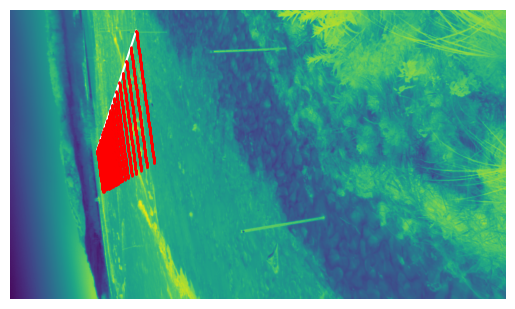

In [42]:
# Placing STIV lines - parallel to horizon (using χcalculated_SC_8_1.σ)
# Find points at edge of image from each start point
function bottom_edge_intersection(start_points_uv, σ, Img_dims)
    bottom_v = Img_dims[1]
    intersections = Vector{Union{Tuple{Int,Int}, Nothing}}(undef, length(start_points_uv))

    for (i, (u0, v0)) in enumerate(start_points_uv)
        sinσ = sin(σ)
        cosσ = cos(σ)

        if sinσ > 0  # Line goes downward
            t = (bottom_v - v0) / -sinσ
            u_edge = u0 + t * cosσ

            # Ensure horizontal coordinate is within image bounds
            if 1 ≤ u_edge ≤ Img_dims[2]
                intersections[i] = (round(Int, u_edge), bottom_v)
            else
                intersections[i] = nothing
            end
        else
            # Line does not reach bottom
            intersections[i] = nothing
        end
    end

    return intersections
end
bottom_edge_points = bottom_edge_intersection(start_points_uv, χcalculated_SC_8_1.σ, Img_dims)

# Bresenham line to find pixels for STIV 
all_lines_pixels = Vector{Vector{Tuple{Int,Int}}}(undef, length(start_points_uv))
for i in 1:length(start_points_uv)
    start_uv = start_points_uv[i]
    edge_uv = bottom_edge_points[i]

    if edge_uv !== nothing
        # Compute Bresenham line between start and edge
        all_lines_pixels[i] = bresenham_line(start_uv[1], start_uv[2], edge_uv[1], edge_uv[2])
    else
        all_lines_pixels[i] = Tuple{Int,Int}[]  # empty line if no intersection
    end
end
all_lines_pixels

# Convert to xy coords
true_lines_pixels = [
    [(u, v) for (u, v) in zip(
        IRQIV.RemoveRadialDistortion(first.(line), last.(line), Camera)...
    )]
    for line in all_lines_pixels
]
true_lines_xy = [
    begin
        xy_line = Vector{Tuple{Float64, Float64}}(undef, length(line))
        for (coord_ind, (u_ind, v_ind)) in enumerate(line)
            x_coord, y_coord = IRQIV.uvz2xy(u_ind, v_ind, SC4_bot_z, dlt)
            xy_line[coord_ind] = (x_coord, y_coord)
        end
        xy_line
    end
    for line in true_lines_pixels
]

# Clip to set range for each line
function clip_indices_within_distance(transect_xy_lines, max_distance)
    clipped_indices = Vector{Vector{Int}}(undef, length(transect_xy_lines))

    for (i, line) in enumerate(transect_xy_lines)
        start_point = line[1]
        inds = Int[]

        for (j, point) in enumerate(line)
            dx = point[1] - start_point[1]
            dy = point[2] - start_point[2]
            dist = sqrt(dx^2 + dy^2)
            if dist <= max_distance
                push!(inds, j)
            else
                break  # all subsequent points will be farther away
            end
        end

        clipped_indices[i] = inds
    end

    return clipped_indices
end
line_length_m = 5
clipped_lines_pixels = [line[inds] for (line, inds) in 
    zip(all_lines_pixels, clip_indices_within_distance(true_lines_xy, line_length_m))]

# Import matplotlib transforms
import PyCall
import ImageTransformations
PyCall.pyimport("matplotlib")

fig, ax = plt.subplots()
# sc = plt.scatter(DH_survey_u, DH_survey_v, c = DH_survey_WSE_diff, cmap="RdYlGn", zorder = 2)
# plt.scatter(SC_6_uv[1], SC_6_uv[2], color = "white", zorder = 3)
ln = plt.plot([SC_4_uv[1], SC_12_uv[1]], [SC_4_uv[2], SC_12_uv[2]], zorder = 2, c = "white")
# sc2 = plt.scatter(first.(start_points_uv), last.(start_points_uv), c = "black", zorder = 2)
# sc3 = plt.scatter(first.(lines_edge_points), last.(lines_edge_points), c = "black", zorder = 2)
for line_pixels in clipped_lines_pixels
    if !isempty(line_pixels)
        us = first.(line_pixels)
        vs = last.(line_pixels)
        plt.scatter(us, vs, s=0.5, c="red", zorder=2)  # adjust s for marker size
    end
end
im = ax.imshow(IRimages[1], extent = (0, size(IRimages)[2], size(IRimages)[1], 0), zorder = 1)
ax.axis("off")
# plt.colorbar(sc, label = "GCP vertical distance from WSE (m)")

plt.gcf()


In [43]:
# Fujita STIV setup

import Images
import FFTW

function point_in_polygon(poly_xs::Vector{T}, poly_ys::Vector{T}, x::T, y::T) where T<: Real
    n_verts = length(poly_xs)
    j = n_verts
    c = false
    for i in 1:n_verts
        if (((poly_ys[i] <= y) && (y < poly_ys[j])) || ((poly_ys[j] <= y) && (y < poly_ys[i]))) && 
            (x < (poly_xs[j] - poly_xs[i]) * (y - poly_ys[i]) / (poly_ys[j] - poly_ys[i]) + poly_xs[i])
            c = !c
        end
        j = i
    end
    return c
end

# Changed these two functions to use bool matrix instead of values
function draw_polygon!(mask::Matrix{Bool}, poly_xs::Vector{Int}, poly_ys::Vector{Int})
    min_x, max_x = max(minimum(poly_xs), 1), min(maximum(poly_xs), size(mask, 2))
    min_y, max_y = max(minimum(poly_ys), 1), min(maximum(poly_ys), size(mask, 1))
    for y in min_y:max_y
        for x in min_x:max_x
            if point_in_polygon(poly_xs, poly_ys, x, y)
                mask[y, x] = true
            end
        end
    end
end

function polygons_to_mask(polygons::Array{Matrix{T}, 1} where T <: Real, max_x::Int, max_y::Int)::Matrix{Bool}
    poly_mask = zeros(Bool, max_y, max_x)  # Initialize a Bool matrix with all values set to false
    for p in polygons
        draw_polygon!(poly_mask, round.(Int, p[:, 1]), round.(Int, p[:, 2]))
    end
    return poly_mask
end

function centered_moving_average(vs, n)
    len = length(vs)
    vs_extended = vcat(vs[end-div(n,2)+1:end], vs, vs[1:div(n,2)])  # Wrap around
    return [sum(@view vs_extended[i:(i+n-1)]) / n for i in 1:len]
end

function max_centered_array_size(x::Int64, y::Int64, dims::Tuple{Int, Int})
    # Extract rows and cols from the dims tuple
    rows, cols = dims
    
    # Compute the max possible radius within bounds
    max_radius = min(y - 1, rows - y, x - 1, cols - x)
    
    # Compute the index ranges for rows and columns
    col_range = (x - max_radius):(x + max_radius)
    row_range = (y - max_radius):(y + max_radius)
    
    return row_range, col_range
end

function distribute_points_centered(n::Int, dims::Tuple{Int, Int})
    rows, cols = dims

    # Ensure the image has an odd number of rows
    if rows % 2 == 0
        rows -= 1  # Exclude the last row if rows is even
    end
    
    # Calculate the center row of the image
    center_row = div(rows, 2) + 1
    
    # Calculate the spacing between points along the center row
    # The leftmost point will be placed a fixed distance from the edge, and the rightmost point will be the same distance from the opposite edge.
    padding = center_row # Padding between points and from the edges
    spacing = div(cols - 2 * padding, n - 1)  # Adjusted spacing between points
    
    # Create an empty list to store the coordinates
    points = []
    
    # Place the leftmost and rightmost points with equal distance from the edges
    leftmost_col = padding
    rightmost_col = cols - padding
    
    # Add the leftmost and rightmost points
    push!(points, (center_row, leftmost_col))
    
    # Distribute the remaining points evenly between the leftmost and rightmost points
    for i in 1:n-2
        col = leftmost_col + (spacing * i)
        push!(points, (center_row, col))
    end
    
    push!(points, (center_row, rightmost_col))
    
    return points
end

function calculate_x_range(slope, x_center, y_center, image_height)
    # Calculate x-values for the top and bottom of the image
    y_top = 1
    y_bottom = image_height

    # Calculate the corresponding x-values for the top and bottom rows
    x_top = (y_top - y_center) / slope + x_center
    x_bottom = (y_bottom - y_center) / slope + x_center

    # Return the range of x-values covered by the line
    x_min = min(x_top, x_bottom)
    x_max = max(x_top, x_bottom)

    return Int(round(x_min)), Int(round(x_max))
end

function find_peaks_and_midpoints(
    img::AbstractMatrix,
    n_peaks::Int,
    m_midpoints::Int,
    buffer::Int
)
    height, width = size(img)
    row_idx = ceil(Int, height / 2)
    row_vals = img[row_idx, :]

    half_height = div(height, 2)

    # Allowed columns (exclude edges within half height)
    allowed_cols = collect((half_height+1):(width - half_height))
    allowed_vals = row_vals[allowed_cols]

    # --- Find n highest peaks ---
    # Sort by descending intensity
    sorted_peak_indices = sortperm(allowed_vals, rev=true)
    selected_peaks = Int[]

    for idx in sorted_peak_indices
        col = allowed_cols[idx]
        # Ensure buffering between peaks
        if all(abs(col - c) > buffer for c in selected_peaks)
            push!(selected_peaks, col)
            if length(selected_peaks) == n_peaks
                break
            end
        end
    end

    # --- Find m mid-intensity points ---
    # Intensity midpoint
    min_val, max_val = extrema(allowed_vals)
    mid_val = (max_val + min_val) / 2

    # Filter out cols too close to peaks
    non_peak_cols = [c for c in allowed_cols if all(abs(c - p) > buffer for p in selected_peaks)]
    non_peak_vals = row_vals[non_peak_cols]

    diffs = abs.(non_peak_vals .- mid_val)
    sorted_mid_indices = sortperm(diffs)
    selected_mids = Int[]

    for idx in sorted_mid_indices
        col = non_peak_cols[idx]
        # Ensure buffering between midpoints themselves
        if all(abs(col - c) > buffer for c in selected_mids)
            push!(selected_mids, col)
            if length(selected_mids) == m_midpoints
                break
            end
        end
    end

    # Combine and sort results as (row, col) tuples
    peaks = [(row_idx, c) for c in sort(selected_peaks)]
    mids = [(row_idx, c) for c in sort(selected_mids)]

    return peaks, mids
end

"""
    find_strong_local_maxima(signal; radius=1)

Find indices of local maxima in `signal` such that each candidate
is strictly greater than all values within ±radius.
"""
function find_strong_local_maxima(signal::AbstractVector; radius::Int=1)
    n = length(signal)
    peaks = Int[]
    for i in (1+radius):(n-radius)
        neighborhood = signal[(i-radius):(i+radius)]
        if signal[i] == maximum(neighborhood) && count(==(signal[i]), neighborhood) == 1
            push!(peaks, i)
        end
    end
    return peaks
end

function find_isolated_peak(signal::AbstractVector, zero_idx::Int, global_idx::Int;
                            radius::Int=1, buffer::Int=0)
    lo, hi = minmax(zero_idx, global_idx)
    lo = max(lo, 1)                   # ensure ≥ 1
    hi = min(hi, length(signal))      # ensure ≤ signal length

    # Step 1: local maxima in restricted range
    candidates = find_strong_local_maxima(signal; radius=radius)

    # Exclude near-zero_idx (within buffer) and outside lo/hi
    candidates = filter(i -> lo < i < hi && abs(i - zero_idx) > buffer, candidates)

    if isempty(candidates)
        return nothing
    end

    best_peak, best_score = nothing, -Inf

    for i in candidates
        # Left span until beaten
        left_span = 0
        for j in (i-1):-1:lo
            if signal[j] > signal[i]
                break
            end
            left_span += 1
        end

        # Right span until beaten
        right_span = 0
        for j in (i+1):hi
            if signal[j] > signal[i]
                break
            end
            right_span += 1
        end

        isolation_score = (left_span + right_span) / 2

        if isolation_score > best_score
            best_score = isolation_score
            best_peak = i
        end
    end

    return best_peak, signal[best_peak], best_score
end

function find_isolated_peak(signal::AbstractVector, zero_idx::Int, global_idx::Int;
                            radius::Int=1, buffer::Int=0)
    lo, hi = minmax(zero_idx, global_idx)
    lo = max(lo, 1)                   # ensure ≥ 1
    hi = min(hi, length(signal))      # ensure ≤ signal length

    # Step 1: local maxima in restricted range
    candidates = find_strong_local_maxima(signal; radius=radius)

    # Exclude near-zero_idx (within buffer) and outside lo/hi
    candidates = filter(i -> (lo < i < hi) && abs(i - zero_idx) > buffer, candidates)

    if isempty(candidates)
        return nothing
    end

    # Find candidate closest to the wave peak (global_idx)
    best_peak_idx = candidates[argmin(abs.(candidates .- global_idx))]

    # Compute isolation score for reference
    left_span = 0
    for j in (best_peak_idx-1):-1:lo
        if signal[j] > signal[best_peak_idx]
            break
        end
        left_span += 1
    end

    right_span = 0
    for j in (best_peak_idx+1):hi
        if signal[j] > signal[best_peak_idx]
            break
        end
        right_span += 1
    end

    isolation_score = (left_span + right_span) / 2

    return best_peak_idx, signal[best_peak_idx], isolation_score
end

function align_zero_min_expand(ax_ref, ax_target; pad_frac=0.02)
    """
    Align y=0 on ax_target to ax_ref, expanding ax_target's span
    by the minimal amount needed (plus pad_frac) so no data is cut off.
    """
    # 1) Reference zero relative position
    y0r, y1r = ax_ref.get_ylim()
    rel0 = (0 - y0r) / (y1r - y0r)

    # 2) Target data extents
    dmin, dmax = ax_target.dataLim.ymin, ax_target.dataLim.ymax
    pad = pad_frac * (dmax - dmin)

    # 3) Compute required spans so data + pad fit above and below zero:
    #    below zero we need b ≤ dmin - pad  where b = -rel0*s
    #    above zero we need b + s ≥ dmax + pad  ⇒ -rel0*s + s ≥ dmax + pad
    # Solve each:
    s_req1 = (dmax + pad) / (1 - rel0)
    s_req2 = -(dmin - pad) / rel0

    # 4) Take the largest requirement, or keep original if it's already big enough
    y0t, y1t = ax_target.get_ylim()
    orig_span = y1t - y0t
    new_span = max(orig_span, s_req1, s_req2)

    # 5) Compute new bottom b so that zero is at rel0 * new_span
    new_y0 = -rel0 * new_span
    new_y1 = new_y0 + new_span

    ax_target.set_ylim(new_y0, new_y1)
    ax_ref.axhline(0, color="gray", linewidth=1)
end

align_zero_min_expand (generic function with 1 method)

In [ ]:
using Interpolations
import ImageContrastAdjustment as ICA
import DSP

# STIV setup
moving_avg_n = 5
AngleIncrement = 1
AngleVec = 1:1*AngleIncrement:180
μ = zeros(Float64, length(AngleVec))
center = Int(ceil(nfiles/2))
radius = center-1
θ_c = range(1, stop = 360, length = 360)
xc = radius * cosd.(θ_c) .+ center
yc = radius * sind.(θ_c) .+ center
circ_mask = polygons_to_mask([hcat(xc, yc)], center+radius, center+radius)
circ_nan = ones(Float64, size(circ_mask))
circ_nan[.!circ_mask] .= NaN

Sx = line_length_m/nfiles
St = 1/IRimages.Metadata.Estimatedfps
k = 0.85 # velocity index

depths = fill(NaN, n_verticals)
velocities = fill(NaN, n_verticals)

# Select IR image file:
FLIR_filename = raw"/Volumes/ETH_4TB/DH_IR/Rec-HRE_2023_-003723-__TIME__.ats"
# Load IR images (from Sutter Slough):
nfiles = 201 # approx. 10 sec
file_step_factors = 1:17
file_step_factors = round.(Int, range(101, stop = 3500, length = 17)) .- 100
file_step = 1

depths = fill(NaN, length(file_step_factors), n_verticals)
velocities = fill(NaN, length(file_step_factors), n_verticals)

for file_step in 1:length(file_step_factors)
    # IRimages = LoadATSImageSequence(FLIR_filename, 
    #     (file_step-1)*nfiles+1:file_step*nfiles, 2023)
    IRimages = LoadATSImageSequence(FLIR_filename, 
        file_step_factors[file_step]:file_step_factors[file_step]+200, 2023)

    for (line_ind, line) in enumerate(clipped_lines_pixels[2:end])
        # Step 1: Extract physical coordinates along the line
        line_xy = [true_lines_xy[line_ind][coord] for coord in 1:length(line)]
        x_coords = [p[1] for p in line_xy]  # physical x
        y_coords = [p[2] for p in line_xy]  # physical y
        
        # Step 2: Collect pixel intensities along the line for each image
        STIV_diagram = zeros(length(line), nfiles)
        for img = 1:nfiles
            image = IRimages[:,:,img] .- mean(IRimages[:,:,img])
            for (coord, (j,i)) in enumerate(line)
                STIV_diagram[coord, img] = image[i,j]
            end
        end


        # Step 3: Interpolate along the line to nfiles points
        interp_coords = range(1, stop=length(line), length=nfiles)
        STIV_square = zeros(nfiles, nfiles)
        for t in 1:nfiles
            itp = interpolate((1:length(line),), STIV_diagram[:,t], Gridded(Linear()))
            STIV_square[:,t] = itp(interp_coords)
        end
        STIV_square = STIV_square .- median(STIV_square, dims=2)
        STIV_square .-= mean(STIV_square)
        # orig_min, orig_max = extrema(STIV_square)
        # STIV_square = STIV_square .* (orig_max - orig_min) .+ orig_min
        STIV_square = ICA.adjust_histogram(STIV_square, ICA.GammaCorrection(gamma=2))
        # STIV_square = ICA.adjust_histogram(STIV_square, ICA.ContrastStretching(; t = 0.7))

        using Statistics

        # imgf = float.(STIV_square)        # ensure Float
        # minv, maxv = minimum(imgf), maximum(imgf)
        # qs = quantile(vec(imgf), [0.5, 0.9, 0.95, 0.99, 0.995])

        # println("min, max = ", minv, ", ", maxv)
        # println("median, p90, p95, p99, p99.5 = ", qs)


        # Step 4: run STIV
        # Compute the 2D Fourier transform and the power spectrum
        Rxy = FFTW.ifft(abs.(FFTW.fft(STIV_square)).^2) ./ length(STIV_square)
        Rxy = FFTW.fftshift(abs.(Rxy)) # Seems important - shifts zero-frequency component to center of spectrum
        θ = zeros(Float64, nfiles, nfiles)
        ρ = zeros(Float64, nfiles, nfiles)
        Tx = zeros(Float64, nfiles, nfiles)
        Ty = zeros(Float64, nfiles, nfiles)
        M = 15  # "coefficient of intensification"

        for i in 1:nfiles
            for j in 1:nfiles
                if circ_mask[i, j]
                    Tx[i,j] = center - j
                    Ty[i,j] = center - i
                    θ[i,j] = atand(Ty[i,j] / Tx[i, j]) # -90 to 90
                    ρ[i,j] = M * log(sqrt(Tx[i,j]^2 + Ty[i,j]^2)) 
                end
            end
        end
        # Apply the circular mask to Rxy
        Rxy_pol_norm = Rxy .* circ_nan ./ Rxy[center, center]
        ρ = ρ .* circ_nan
        θ = θ .* circ_nan
        
        # Aggregate by polar coordinates
        inds_vec = zeros(Int, length(AngleVec))
        μ = zeros(Float64, length(AngleVec))
        ρ_max = M*log(minimum([maximum(filter(!isnan,Tx)),maximum(filter(!isnan,Ty))]))
        for i in 1:length(AngleVec)
            a = i-90 # Convert index back to angle of theta
            inds = findall(θ -> round(θ) == a, θ[:])
            inds_vec[i] = length(inds)
            Rxy_int = sum(Rxy_pol_norm[inds])/inds_vec[i] # Normalize by # of pixels within each degree - varies widely!
            # Rxy_int = sum(Rxy_pol_norm[inds])^2/inds_vec[i] # Flight C
            μ[i] = (1/ρ_max)*Rxy_int
        end
        μ_avg = centered_moving_average(μ, moving_avg_n)
        φ = argmax(μ_avg) - 90
        μ_norm = μ_avg ./ maximum(μ_avg)

        if φ == 90 || φ >= 0
            continue
        end

        result = find_isolated_peak(μ_avg, 90, φ+90; radius = 5, buffer = 10)
        if result === nothing # If can't find bulk vel, can't correct wave speed
            continue
        end
        bulk_idx, _, _ = result
        bulk_angle = AngleVec[bulk_idx] - 90

        bulk_vel = Sx/St*tand(bulk_angle)
        wave_vel = Sx/St*tand(φ) - bulk_vel
        depth = wave_vel^2/9.81
        if depth > 1
            continue
        end

        velocities[file_step, line_ind] = bulk_vel * k
        depths[file_step, line_ind] = depth
        
        # Create figure
        ts_rounded = Dates.Time.(
            round.(DateTime.(IRQIV.ats_ts(IRimages)), 
                Dates.Second))
        xtick_inds = 1:40:nfiles
        xtick_labels = [string(ts_rounded[ind]) for ind in xtick_inds]
        ytick_inds = 1:40:nfiles
        ytick_labels = round.(Int, range(0, stop=line_length_m, length=nfiles)[ytick_inds])

        # Subplot: Rxy image with detected angle
        plot_angle_wave = φ  # Adjust for image coordinate system
        xEdge_wave = center + radius * cosd(plot_angle_wave)
        yEdge_wave = center + radius * sind(plot_angle_wave)

        plot_angle_bulk = bulk_angle  # Adjust for image coordinate system
        xEdge_bulk = center + radius * cosd(plot_angle_bulk)
        yEdge_bulk = center + radius * sind(plot_angle_bulk)

        STIV_diagram = hcat(STIV_diagram...)
        plt.close("all")
        # fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10, 4))
        # fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(10, 3))

        # plt.title("STIV line $line_ind")
        # ax1.set_title("Velocity = $(round(abs(bulk_vel), digits = 2)) m/s, Depth = $(round(depth, digits = 2)) m (Line # $line_ind)")
        # im1 = ax1.imshow(STIV_square, origin="lower", aspect="equal", cmap="viridis")
        # ax1.plot([center, xEdge_wave], [center, yEdge_wave], color="red", lw=2)
        # ax1.plot([center, xEdge_bulk], [center, yEdge_bulk], color="orange", lw=2)
        # plt.colorbar(im1, ax = ax1, label="Intensity")
        # ax1.set_yticks(ytick_inds, ytick_labels)
        # ax1.set_ylabel("Line position (m)")
        # ax1.set_xticks(xtick_inds, xtick_labels, rotation=45)
        # ax1.set_xlabel("Time on August 1, 2023")

        # ax2.set_title("Wave = $(φ)°, bulk = $(bulk_angle)°")
        # ax2.plot(AngleVec.-90, μ_norm)
        # ax2.set_xlabel("Angle (degrees)")
        # ax2.set_ylabel("Normalized autocorrelation")
        # # ax2.axvline(wave_idx-90)
        # # ax2.axvline(bulk_idx-90)
        # ax2.axvline(φ, color = "red")
        # ax2.axvline(bulk_angle, color = "orange")

        # ax3.set_title("Space-time diagram histogram")
        # ax3.hist(vec(STIV_square), bins = 51)

        # plt.tight_layout()
        
        # plt.display(fig)
    end
end

# velocities = velocities[1,:]
# depths = depths[1,:]

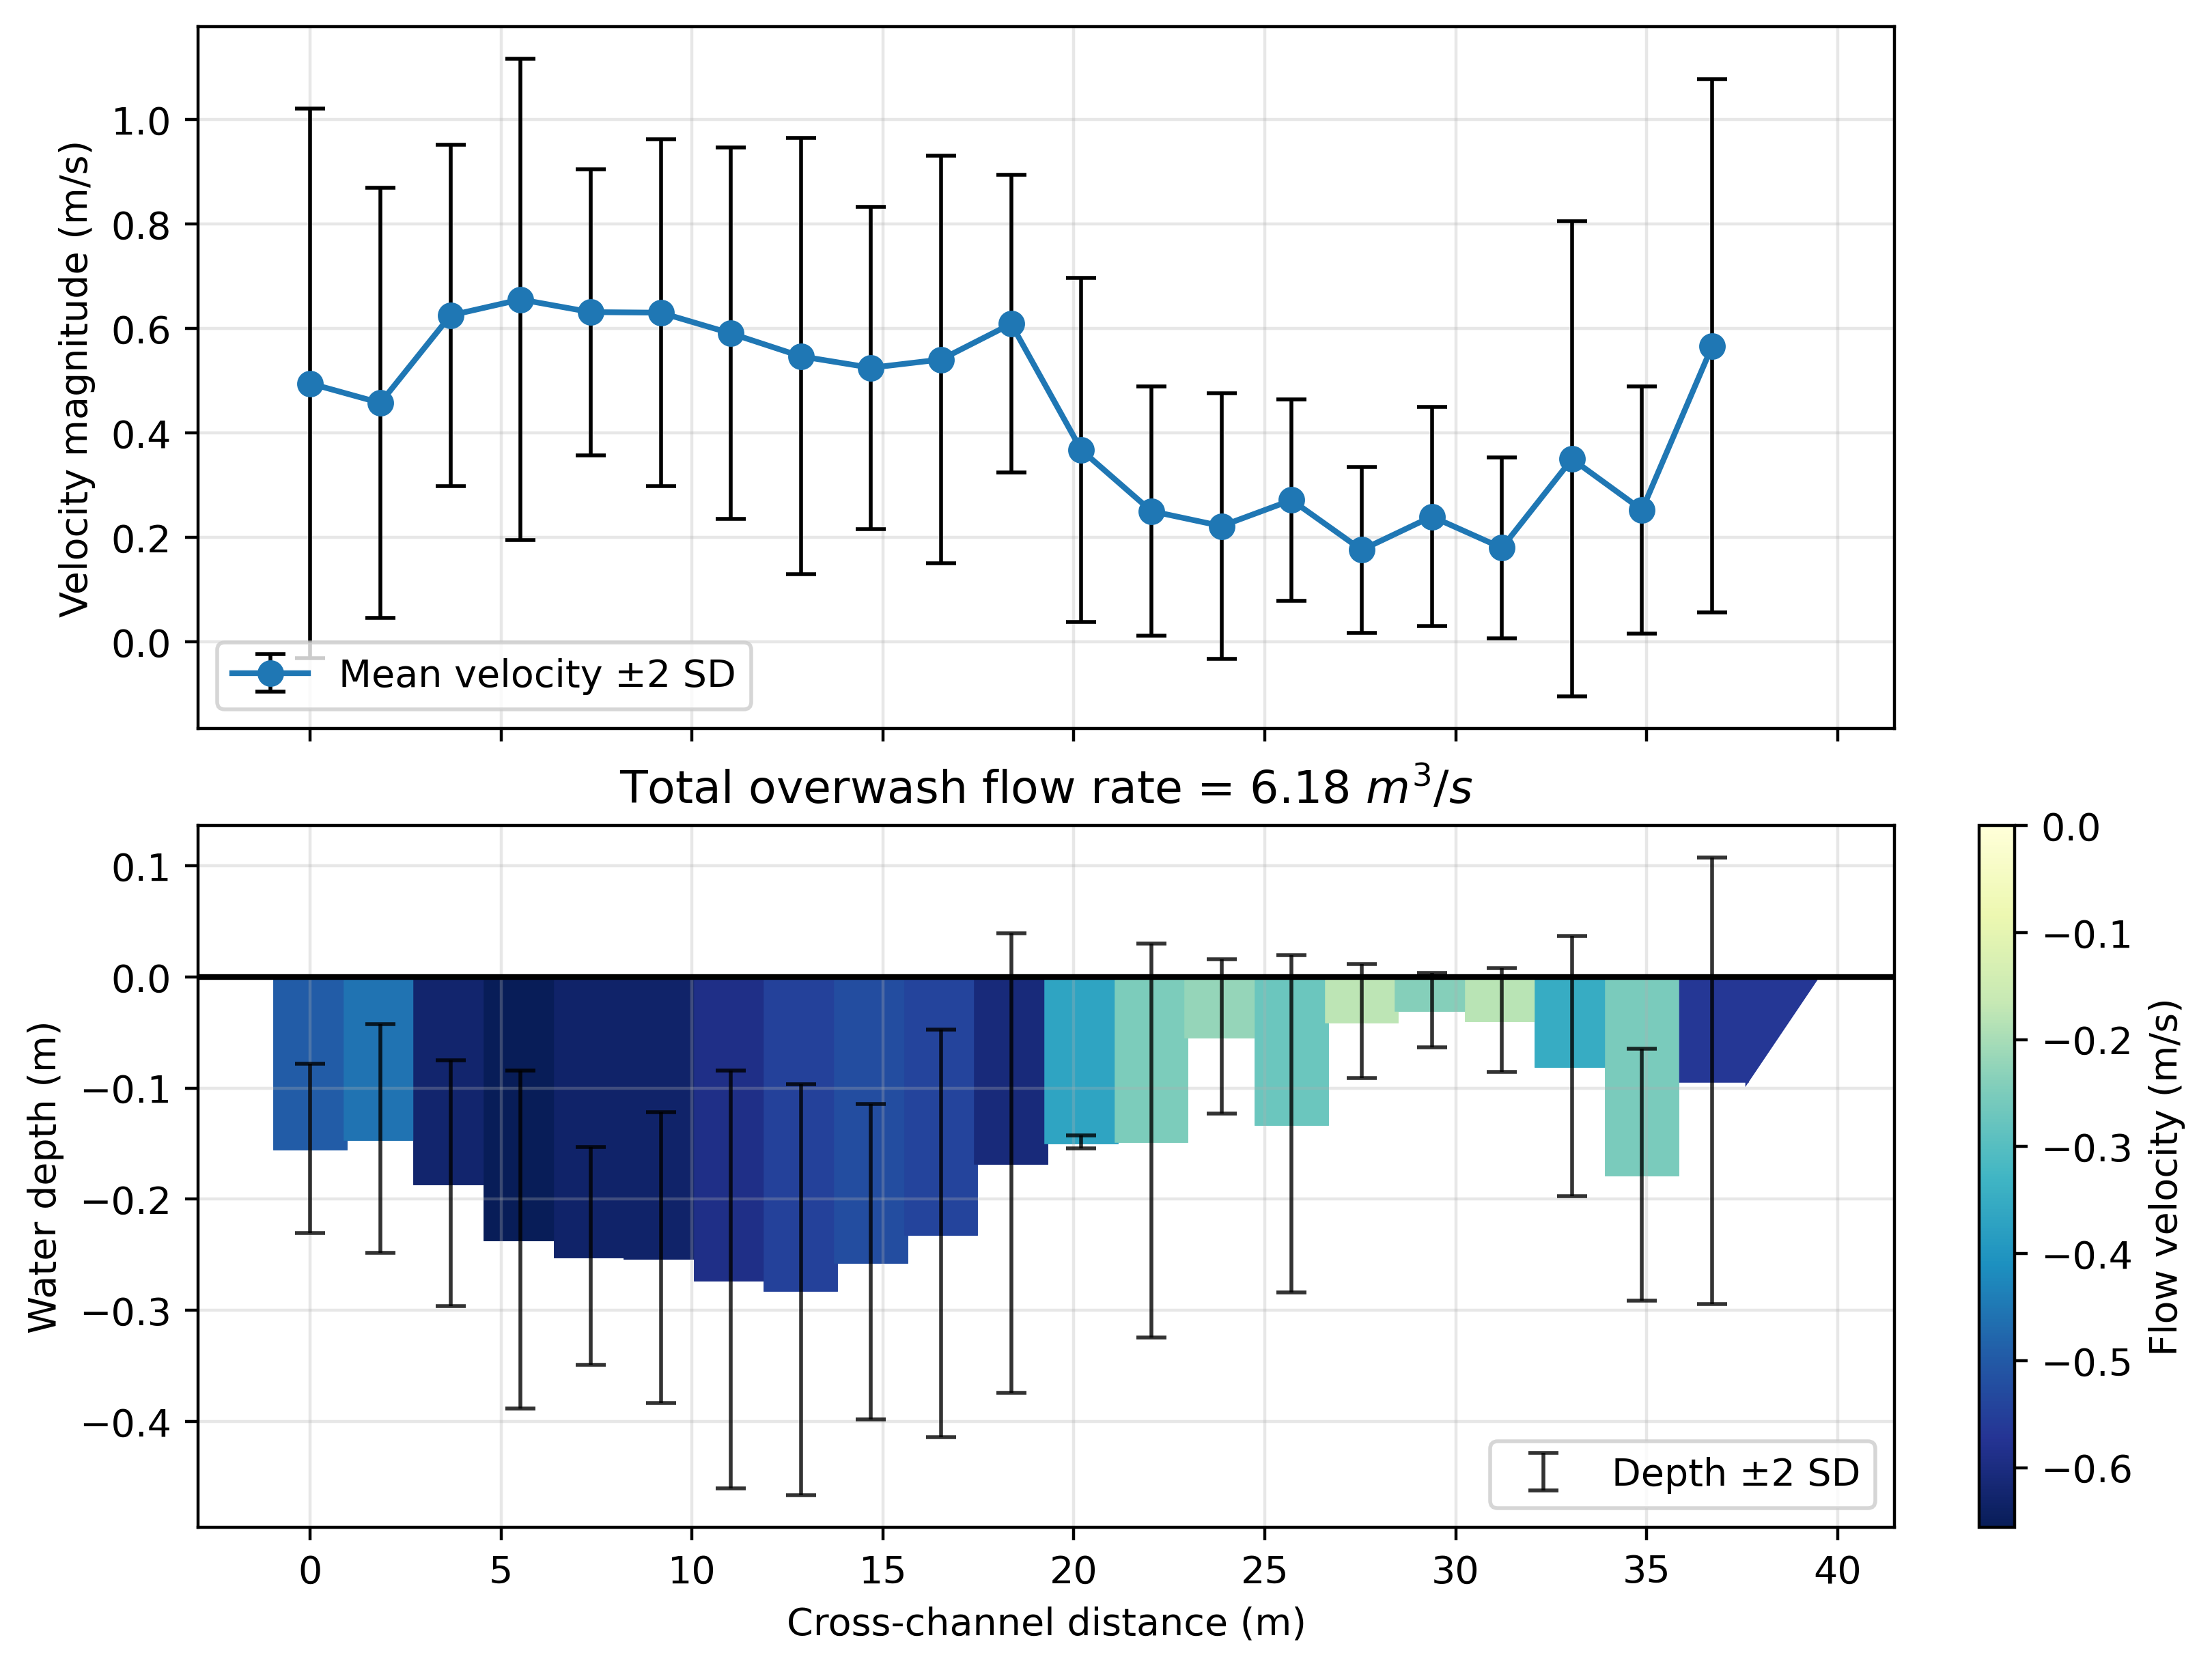

In [61]:
import StaticArrays, LinearAlgebra

function normal_component(stiv_line_xy, ref_start_xy, ref_end_xy, v_stiv)
    # Reference transect direction
    ref_vec = StaticArrays.SVector(ref_end_xy...) - StaticArrays.SVector(ref_start_xy...)
    ref_unit = ref_vec / LinearAlgebra.norm(ref_vec)

    # STIV line direction (first → last point of this line)
    stiv_vec = StaticArrays.SVector(stiv_line_xy[end]...) - StaticArrays.SVector(stiv_line_xy[1]...)
    stiv_unit = stiv_vec / LinearAlgebra.norm(stiv_vec)

    # Angle between STIV line and transect
    cosθ = clamp(LinearAlgebra.dot(stiv_unit, ref_unit), -1, 1)
    θ = acosd(cosθ)

    # Normal component of STIV velocity
    return v_stiv * sind(θ), θ
end

ref_start_xy = true_lines_xy[1][1]   # first point of first line
ref_end_xy   = true_lines_xy[end][1] # first point of last line

velocities_normal = fill(NaN, length(file_step_factors), n_verticals)
# velocities_normal = fill(NaN, 17, n_verticals)

for t in 1:length(file_step_factors)
# for t in 1:17
    for n in 1:n_verticals
        stiv_line = true_lines_xy[n]          # line geometry for vertical n
        v_stiv = velocities[t, n]         # raw velocity magnitude (your input)
        v_norm, θ = normal_component(stiv_line, ref_start_xy, ref_end_xy, v_stiv)

        # depths[t, n] = θ                      # store angle (or whatever metric you want)
        velocities_normal[t, n] = v_norm              # store normal velocity
    end
end

# Example data
indices = 1:22

# Filter: mask out shallow bins (≤ 1 m)
# mask = depths .>= 1.0
# depths[mask] .= NaN
# velocities[mask] .= NaN

mean_depths = NaNStatistics.nanmean(depths, dims = 1)[:]
mean_velocities = NaNStatistics.nanmean(velocities_normal, dims = 1)[:]
# mean_depths = depths[1,:]
# mean_velocities = velocities[1,:]
# mean_depths = depths
# mean_velocities = velocities

std_depths = NaNStatistics.nanstd(depths, dims = 1)[:]
std_velocities  = NaNStatistics.nanstd(velocities_normal, dims=1)[:]

# Colormap
cmap = plt.cm.YlGnBu_r
valid_vels = mean_velocities[.!isnan.(mean_velocities)]
norm_colors = plt.matplotlib.colors.Normalize(vmin=minimum(valid_vels), vmax=0)

fig, (ax_vel, ax_depth) = plt.subplots(2, 1, 
    figsize=(8, 6), dpi=400, constrained_layout=true, sharex=true)

dx = step(distances)
physical_x = (indices .- 1) .* dx
total_discharge = 0.0

valid_idx = findall(x -> !isnan(x), mean_depths)

# ===== Top subplot: velocity profile with ±2 SD error bars =====
ax_vel.errorbar(
    physical_x, -mean_velocities,
    yerr = 2 .* std_velocities,
    fmt = "o-", color = "tab:blue",
    ecolor = "black", elinewidth = 1, capsize = 4,
    label = "Mean velocity ±2 SD"
)

ax_vel.set_ylabel("Velocity magnitude (m/s)")
# ax_vel.set_title("Cross-channel profiles")
ax_vel.grid(true, alpha=0.3)
ax_vel.legend(loc="lower left")

# ===== Bottom subplot: depth profile color-coded by velocity =====
ax_depth.grid(true, alpha=0.3)

for (i, x) in enumerate(physical_x)
    z = mean_depths[i]
    v = mean_velocities[i]
    if !isnan(z) && !isnan(v)
        color = cmap(norm_colors(v))
        ax_depth.fill(
            [x - dx/2, x + dx/2, x + dx/2, x - dx/2],
            [0, 0, -z, -z],
            color = color, edgecolor = "k"
        )
        total_discharge += dx * z * v
    end
end

# Handle triangular edges
first_valid = findfirst(x -> !isnan(x), mean_depths)
if first_valid !== nothing && first_valid > 1
    z = mean_depths[first_valid]
    v = mean_velocities[first_valid]
    color = cmap(norm_colors(v))
    base = physical_x[first_valid] - physical_x[1]
    ax_depth.fill(
        [physical_x[1]-dx/2, physical_x[first_valid]-dx/2, physical_x[first_valid]-dx/2],
        [0, 0, -z],
        color = color, edgecolor = "k"
    )
    total_discharge += 0.5 * base * z * v
end

for k in 1:(length(valid_idx)-1)
    i = valid_idx[k]
    j = valid_idx[k+1]
    z_i, z_j = mean_depths[i], mean_depths[j]
    v_i, v_j = mean_velocities[i], mean_velocities[j]

    if j == i + 1
        ax_depth.fill(
            [physical_x[i]-dx/2, physical_x[i]+dx/2, physical_x[i]+dx/2, physical_x[i]-dx/2],
            [0, 0, -z_i, -z_i],
            color = cmap(norm_colors(v_i)), edgecolor = "k"
        )
        total_discharge += dx * z_i * v_i
    else
        x_left = physical_x[i] + dx/2
        x_right = physical_x[j] - dx/2
        ax_depth.fill(
            [x_left, x_right, x_right, x_left],
            [0, 0, -z_j, -z_i],
            color = cmap(norm_colors((v_i+v_j)/2)), edgecolor = "k"
        )
        base = x_right - x_left
        area = 0.5 * (z_i + z_j) * base
        total_discharge += area * ((v_i + v_j) / 2)
    end
end

last_valid = findlast(x -> !isnan(x), mean_depths)
if last_valid !== nothing && last_valid < n_verticals
    z = mean_depths[last_valid]
    v = mean_velocities[last_valid]
    color = cmap(norm_colors(v))
    base = physical_x[end] - physical_x[last_valid]
    ax_depth.fill(
        [physical_x[last_valid]+dx/2, physical_x[end]+dx/2, physical_x[last_valid]+dx/2],
        [0, 0, -z],
        color = color, edgecolor = "k"
    )
    total_discharge += 0.5 * base * z * v
end


# Depth error bars (±2 SD)
ax_depth.errorbar(
    physical_x, -mean_depths,
    yerr = 2 .* std_depths,
    fmt = "none", ecolor = "black",
    elinewidth = 1, capsize = 4,
    alpha = 0.8,
    label = "Depth ±2 SD"
)

ax_depth.set_xlabel("Cross-channel distance (m)")
ax_depth.set_ylabel("Water depth (m)")
ax_depth.set_title("Total overwash flow rate = $(-round(total_discharge, digits=2)) $(LaTeXStrings.L"m^3/s")")
ax_depth.legend(loc="lower right")
ax_depth.axhline(color = "black")

plt.colorbar(
    plt.cm.ScalarMappable(norm=norm_colors, cmap=cmap),
    ax=ax_depth,
    label="Flow velocity (m/s)"
)


plt.gcf()



In [21]:
# Place STIV lines for shallower flow
WSE = SC6_bot_z # File 3717

FLIR_filename = raw"/Volumes/ETH_4TB/DH_IR/Rec-HRE_2023_-003717-__TIME__.ats"
# FLIR_filename = raw"/Volumes/ETH_4TB/DH_IR/Rec-HRE_2023_-003714-__TIME__.ats"
nfiles = 201 # approx. 10 sec
file_step = 1
IRimages = LoadATSImageSequence(FLIR_filename, (file_step-1)*nfiles+1:file_step*nfiles, 2023)


shallow_range = (253, 310) # Estimated u-intercepts for water edge along same line from SC4 to SC12
transect_shallow_inds = findall(p -> shallow_range[1] ≤ p[1] ≤ shallow_range[2], transect_uv)
transect_xy = fill((0.0, 0.0), length(transect_shallow_inds))
for (coord_ind, coord) in enumerate(true_transect_uv[transect_shallow_inds])
    # v_ind, u_ind = coord
    u_ind, v_ind = coord
    x_coord, y_coord = IRQIV.uvz2xy(u_ind, v_ind, WSE, dlt)
    transect_xy[coord_ind] = (x_coord, y_coord)
end

delta_x = first.(transect_xy)[end] - first.(transect_xy)[1]
delta_y = last.(transect_xy)[end] - last.(transect_xy)[1]
line_length = sqrt(delta_x^2 + delta_y^2)
n_verticals = 22
distances = LinRange(0, line_length, n_verticals)

start_vec = StaticArrays.SVector(transect_xy[1]...)
delta_vec = StaticArrays.SVector(delta_x, delta_y)
# Solve for n points equally spaced
equidistant_points = [start_vec + (distance / line_length) * delta_vec for distance in distances]

start_point_indices = []
for eq_point in equidistant_points
    # Find the pixel in shadow_pixels_xy that has the minimum distance to eq_point
    distances_to_pixels = [LinearAlgebra.norm(eq_point .- pixel) for pixel in transect_xy]
    min_index = argmin(distances_to_pixels)  # Find the index of the minimum distance
    push!(start_point_indices, min_index)
end

start_point_indices

start_points_uv = transect_uv[transect_shallow_inds][start_point_indices]

bottom_edge_points = bottom_edge_intersection(start_points_uv, χcalculated_SC_8_1.σ, Img_dims)

all_lines_pixels = Vector{Vector{Tuple{Int,Int}}}(undef, length(start_points_uv))
for i in 1:length(start_points_uv)
    start_uv = start_points_uv[i]
    edge_uv = bottom_edge_points[i]

    if edge_uv !== nothing
        # Compute Bresenham line between start and edge
        all_lines_pixels[i] = bresenham_line(start_uv[1], start_uv[2], edge_uv[1], edge_uv[2])
    else
        all_lines_pixels[i] = Tuple{Int,Int}[]  # empty line if no intersection
    end
end
all_lines_pixels

# Convert to xy coords
true_lines_pixels = [
    [(u, v) for (u, v) in zip(
        IRQIV.RemoveRadialDistortion(first.(line), last.(line), Camera)...
    )]
    for line in all_lines_pixels
]
true_lines_xy = [
    begin
        xy_line = Vector{Tuple{Float64, Float64}}(undef, length(line))
        for (coord_ind, (u_ind, v_ind)) in enumerate(line)
            x_coord, y_coord = IRQIV.uvz2xy(u_ind, v_ind, SC4_bot_z, dlt)
            xy_line[coord_ind] = (x_coord, y_coord)
        end
        xy_line
    end
    for line in true_lines_pixels
]

line_length_m = 5
clipped_lines_pixels = [line[inds] for (line, inds) in 
    zip(all_lines_pixels, clip_indices_within_distance(true_lines_xy, line_length_m))]

fig, ax = plt.subplots()
for line_pixels in clipped_lines_pixels
    if !isempty(line_pixels)
        us = first.(line_pixels)
        vs = last.(line_pixels)
        plt.scatter(us, vs, s=.5, c="red", zorder=2)  # adjust s for marker size
    end
end
im = ax.imshow(IRimages[1], extent = (0, size(IRimages)[2], size(IRimages)[1], 0), zorder = 1)
plt.show()

In [28]:
# Extract FLIR metadata
FLIR_filename = raw"/Volumes/ETH_4TB/DH_IR/Rec-HRE_2023_-003717-__TIME__.ats"
FLIR_meta_summary = IRQIV.FLIRATSFiles.FindATSFileMetadata(FLIR_filename, ATSfps = NaN, ats_year = 2023)
lastframe = FLIR_meta_summary.EstimatedTotalFrames
_,FLIR_meta_full = IRQIV.FLIRATSFiles.LoadMultipleFrames(FLIR_meta_summary, collect(1:1:lastframe), ats_year=2023, ReadFrame=false)
FLIR_meta_time = TimeZones.ZonedDateTime(
    IRQIV.FLIRATSFiles.ParseBHPHeaderTimestamp(FLIR_meta_full, ats_year = 2023)[1], # First frame corresponds to file modeified time
    TimeZones.tz"America/New_York"
)

# Extract metadata from file using base functions
file_meta_time = TimeZones.ZonedDateTime(Dates.unix2datetime(stat(FLIR_filename).mtime), TimeZones.tz"UTC")
file_meta_time = TimeZones.astimezone(file_meta_time, TimeZones.tz"America/New_York")

# Calculate and correct for offset between two metadata times
meta_time_offset = FLIR_meta_time - file_meta_time
mid_WL_ts = IRQIV.FLIRATSFiles.ParseBHPHeaderTimestamp(FLIR_meta_full, ats_year = 2023) .- meta_time_offset

# Extract FLIR metadata
FLIR_filename = raw"/Volumes/ETH_4TB/DH_IR/Rec-HRE_2023_-003714-__TIME__.ats"
FLIR_meta_summary = IRQIV.FLIRATSFiles.FindATSFileMetadata(FLIR_filename, ATSfps = NaN, ats_year = 2023)
lastframe = FLIR_meta_summary.EstimatedTotalFrames
_,FLIR_meta_full = IRQIV.FLIRATSFiles.LoadMultipleFrames(FLIR_meta_summary, collect(1:1:lastframe), ats_year=2023, ReadFrame=false)
FLIR_meta_time = TimeZones.ZonedDateTime(
    IRQIV.FLIRATSFiles.ParseBHPHeaderTimestamp(FLIR_meta_full, ats_year = 2023)[1], # First frame corresponds to file modeified time
    TimeZones.tz"America/New_York"
)

# Extract metadata from file using base functions
file_meta_time = TimeZones.ZonedDateTime(Dates.unix2datetime(stat(FLIR_filename).mtime), TimeZones.tz"UTC")
file_meta_time = TimeZones.astimezone(file_meta_time, TimeZones.tz"America/New_York")

# Calculate and correct for offset between two metadata times
meta_time_offset = FLIR_meta_time - file_meta_time
low_WL_ts = IRQIV.FLIRATSFiles.ParseBHPHeaderTimestamp(FLIR_meta_full, ats_year = 2023) .- meta_time_offset

3600-element Vector{DateTime}:
 2023-08-01T22:57:56
 2023-08-01T22:57:56.034
 2023-08-01T22:57:56.100
 2023-08-01T22:57:56.134
 2023-08-01T22:57:56.167
 2023-08-01T22:57:56.234
 2023-08-01T22:57:56.300
 2023-08-01T22:57:56.334
 2023-08-01T22:57:56.367
 2023-08-01T22:57:56.434
 ⋮
 2023-08-01T23:00:55.533
 2023-08-01T23:00:55.567
 2023-08-01T23:00:55.633
 2023-08-01T23:00:55.700
 2023-08-01T23:00:55.733
 2023-08-01T23:00:55.767
 2023-08-01T23:00:55.833
 2023-08-01T23:00:55.900
 2023-08-01T23:00:55.933

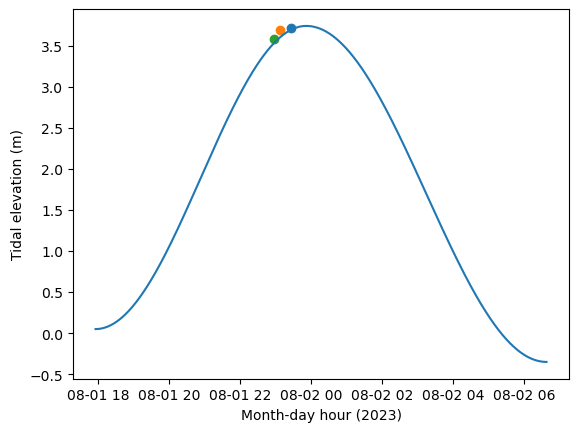

In [41]:
using Dates

tide_hilo = CSV.read(raw"/Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/2023/DH_STIV/Wellfleet_NOAA_tide_predictions.txt",
    DataFrame, skipto = 21, delim = "\t", header = false)
rename!(tide_hilo, [:Date, :DOW, :Time, :Height, :HiLo])

tide_hilo.Date = Dates.Date.(tide_hilo[:,1], "yyyy/mm/dd")
tide_hilo.DateTime .= tide_hilo.Date + tide_hilo.Time

function tidal_cycle(low1_time::DateTime, low1_level::Float64,
                     high_time::DateTime, high_level::Float64,
                     low2_time::DateTime, low2_level::Float64;
                     Δt::Minute = Minute(1))

    times = collect(low1_time:Δt:low2_time)
    levels = Float64[]

    for t in times
        if t <= high_time
            # Low → High: cosine half-wave (flat slope at ends)
            φ = (t - low1_time) / (high_time - low1_time) * π
            push!(levels, low1_level + (high_level - low1_level) * (1 - cos(φ)) / 2)
        else
            # High → Low: cosine half-wave (flat slope at ends)
            φ = (t - high_time) / (low2_time - high_time) * π
            push!(levels, high_level + (low2_level - high_level) * (1 - cos(φ)) / 2)
        end
    end

    return DataFrame(time=times, level=levels)
end


tide_preds = tidal_cycle(tide_hilo.DateTime[11], tide_hilo.Height[11],
    tide_hilo.DateTime[12], tide_hilo.Height[12],
    tide_hilo.DateTime[13], tide_hilo.Height[13])

high_comp_ind = argmin(abs.(tide_preds.time .- high_WL_ts[1]))
high_offset = tide_preds.level[high_comp_ind] - SC4_bot_z
mid_comp_ind = argmin(abs.(tide_preds.time .- mid_WL_ts[1]))
mid_offset = tide_preds.level[mid_comp_ind] - SC6_bot_z
low_comp_ind = argmin(abs.(tide_preds.time .- low_WL_ts[1]))
low_offset = tide_preds.level[high_comp_ind] - SC8_bot_z
mean_offset = mean([high_offset, mid_offset, low_offset])

plt.figure()
plt.plot(tide_preds.time, tide_preds.level)
plt.scatter(high_WL_ts[1], SC4_bot_z+mean_offset)
plt.scatter(mid_WL_ts[1], SC6_bot_z+mean_offset)
plt.scatter(low_WL_ts[1], SC8_bot_z+mean_offset)
# plt.xlim(Dates.DateTime(2022,8,1,22), Dates.DateTime(2022,8,2,2))
# plt.ylim([3.5, 4])
plt.xlabel("Month-day hour (2023)")
plt.ylabel("Tidal elevation (m)")
plt.gcf()

In [33]:
Dates.DateTime(2022,8,2,2)

2022-08-02T02:00:00

In [ ]:
using Interpolations

Sx = line_length_m/nfiles
St = 1/IRimages.Metadata.Estimatedfps

depths = fill(NaN, n_verticals)
velocities = fill(NaN, n_verticals)

# Select IR image file:
# Load IR images (from Sutter Slough):
nfiles = 201 # approx. 10 sec
file_step_factors = 1:17
file_step = 1

depths = fill(NaN, file_step_factors, n_verticals)
velocities = fill(NaN, file_step_factors, n_verticals)

for file_step in file_step_factors
    IRimages = LoadATSImageSequence(FLIR_filename, 
        (file_step-1)*nfiles+1:file_step*nfiles, 2023)

    for (line_ind, line) in enumerate(clipped_lines_pixels[2:end])
        # Step 1: Extract physical coordinates along the line
        line_xy = [true_lines_xy[line_ind][coord] for coord in 1:length(line)]
        x_coords = [p[1] for p in line_xy]  # physical x
        y_coords = [p[2] for p in line_xy]  # physical y
        
        # Step 2: Collect pixel intensities along the line for each image
        STIV_diagram = zeros(length(line), nfiles)
        for img = 1:nfiles
            image = IRimages[:,:,img] .- mean(IRimages[:,:,img])
            for (coord, (j,i)) in enumerate(line)
                STIV_diagram[coord, img] = image[i,j]
            end
        end

        # Step 3: Interpolate along the line to nfiles points
        interp_coords = range(1, stop=length(line), length=nfiles)
        STIV_square = zeros(nfiles, nfiles)
        for t in 1:nfiles
            itp = interpolate((1:length(line),), STIV_diagram[:,t], Gridded(Linear()))
            STIV_square[:,t] = itp(interp_coords)
        end

        # Step 4: run STIV
        # Compute the 2D Fourier transform and the power spectrum
        Rxy = FFTW.ifft(abs.(FFTW.fft(STIV_square)).^2) ./ length(STIV_square)
        Rxy = FFTW.fftshift(abs.(Rxy)) # Seems important - shifts zero-frequency component to center of spectrum
        θ = zeros(Float64, nfiles, nfiles)
        ρ = zeros(Float64, nfiles, nfiles)
        Tx = zeros(Float64, nfiles, nfiles)
        Ty = zeros(Float64, nfiles, nfiles)
        M = 15  # "coefficient of intensification"

        for i in 1:nfiles
            for j in 1:nfiles
                if circ_mask[i, j]
                    Tx[i,j] = center - j
                    Ty[i,j] = center - i
                    θ[i,j] = atand(Ty[i,j] / Tx[i, j]) # -90 to 90
                    ρ[i,j] = M * log(sqrt(Tx[i,j]^2 + Ty[i,j]^2)) 
                end
            end
        end
        # Apply the circular mask to Rxy
        Rxy_pol_norm = Rxy .* circ_nan ./ Rxy[center, center]
        ρ = ρ .* circ_nan
        θ = θ .* circ_nan
        
        # Aggregate by polar coordinates
        inds_vec = zeros(Int, length(AngleVec))
        μ = zeros(Float64, length(AngleVec))
        ρ_max = M*log(minimum([maximum(filter(!isnan,Tx)),maximum(filter(!isnan,Ty))]))
        for i in 1:length(AngleVec)
            a = i-90 # Convert index back to angle of theta
            inds = findall(θ -> round(θ) == a, θ[:])
            inds_vec[i] = length(inds)
            Rxy_int = sum(Rxy_pol_norm[inds])/inds_vec[i] # Normalize by # of pixels within each degree - varies widely!
            # Rxy_int = sum(Rxy_pol_norm[inds])^2/inds_vec[i] # Flight C
            μ[i] = (1/ρ_max)*Rxy_int
        end
        μ_avg = centered_moving_average(μ, moving_avg_n)
        φ = argmax(μ_avg) - 90

        if φ == 90 || φ == 0
            continue
        end

        result = find_isolated_peak(μ_avg, 90, φ+90; radius = 5)
        if result === nothing
            continue
        end
        bulk_idx, _, _ = result
        bulk_angle = AngleVec[bulk_idx] - 90

        bulk_vel = Sx/St*tand(bulk_angle)
        wave_vel = Sx/St*tand(φ) - bulk_vel
        depth = wave_vel^2/9.81

        velocities[file_step, line_ind] = bulk_vel
        depths[file_step, line_ind] = depth
        
        # Create figure
        ts_rounded = Dates.Time.(
            round.(DateTime.(IRQIV.ats_ts(IRimages)), 
                Dates.Second))
        xtick_inds = 1:40:nfiles
        xtick_labels = [string(ts_rounded[ind]) for ind in xtick_inds]
        ytick_inds = 1:40:nfiles
        ytick_labels = round.(Int, range(0, stop=line_length_m, length=nfiles)[ytick_inds])

        # Subplot: Rxy image with detected angle
        plot_angle_wave = φ  # Adjust for image coordinate system
        xEdge_wave = center + radius * cosd(plot_angle_wave)
        yEdge_wave = center + radius * sind(plot_angle_wave)

        plot_angle_bulk = bulk_angle  # Adjust for image coordinate system
        xEdge_bulk = center + radius * cosd(plot_angle_bulk)
        yEdge_bulk = center + radius * sind(plot_angle_bulk)

        # STIV_diagram = hcat(STIV_diagram...)
        plt.close("all")
        fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10, 4))

        # plt.title("STIV line $line_ind")
        ax1.set_title("STIV line # $line_ind: vel = $(round(abs(bulk_vel), digits = 2)) m/s, depth = $(round(depth, digits = 2)) m")
        im1 = ax1.imshow(STIV_square, origin="lower", aspect="equal", cmap="viridis")
        ax1.plot([center, xEdge_wave], [center, yEdge_wave], color="red", lw=2)
        ax1.plot([center, xEdge_bulk], [center, yEdge_bulk], color="orange", lw=2)
        # ax1.colorbar(im1, label="Intensity")
        ax1.set_yticks(ytick_inds, ytick_labels)
        ax1.set_ylabel("Line position (m)")
        ax1.set_xticks(xtick_inds, xtick_labels, rotation=45)
        ax1.set_xlabel("Time on August 1, 2023")

        ax2.set_title("Wave = $(φ)°, bulk = $(bulk_angle)°")
        ax2.plot(AngleVec.-90, μ_avg)
        ax2.set_xlabel("Angle (degrees)")
        ax2.set_ylabel("Normalized autocorrelation")
        # ax2.axvline(wave_idx-90)
        # ax2.axvline(bulk_idx-90)
        ax2.axvline(φ, color = "red")
        ax2.axvline(bulk_angle, color = "orange")

        plt.display(fig)
    end
end

# velocities = velocities[1,:]
# depths = depths[1,:]

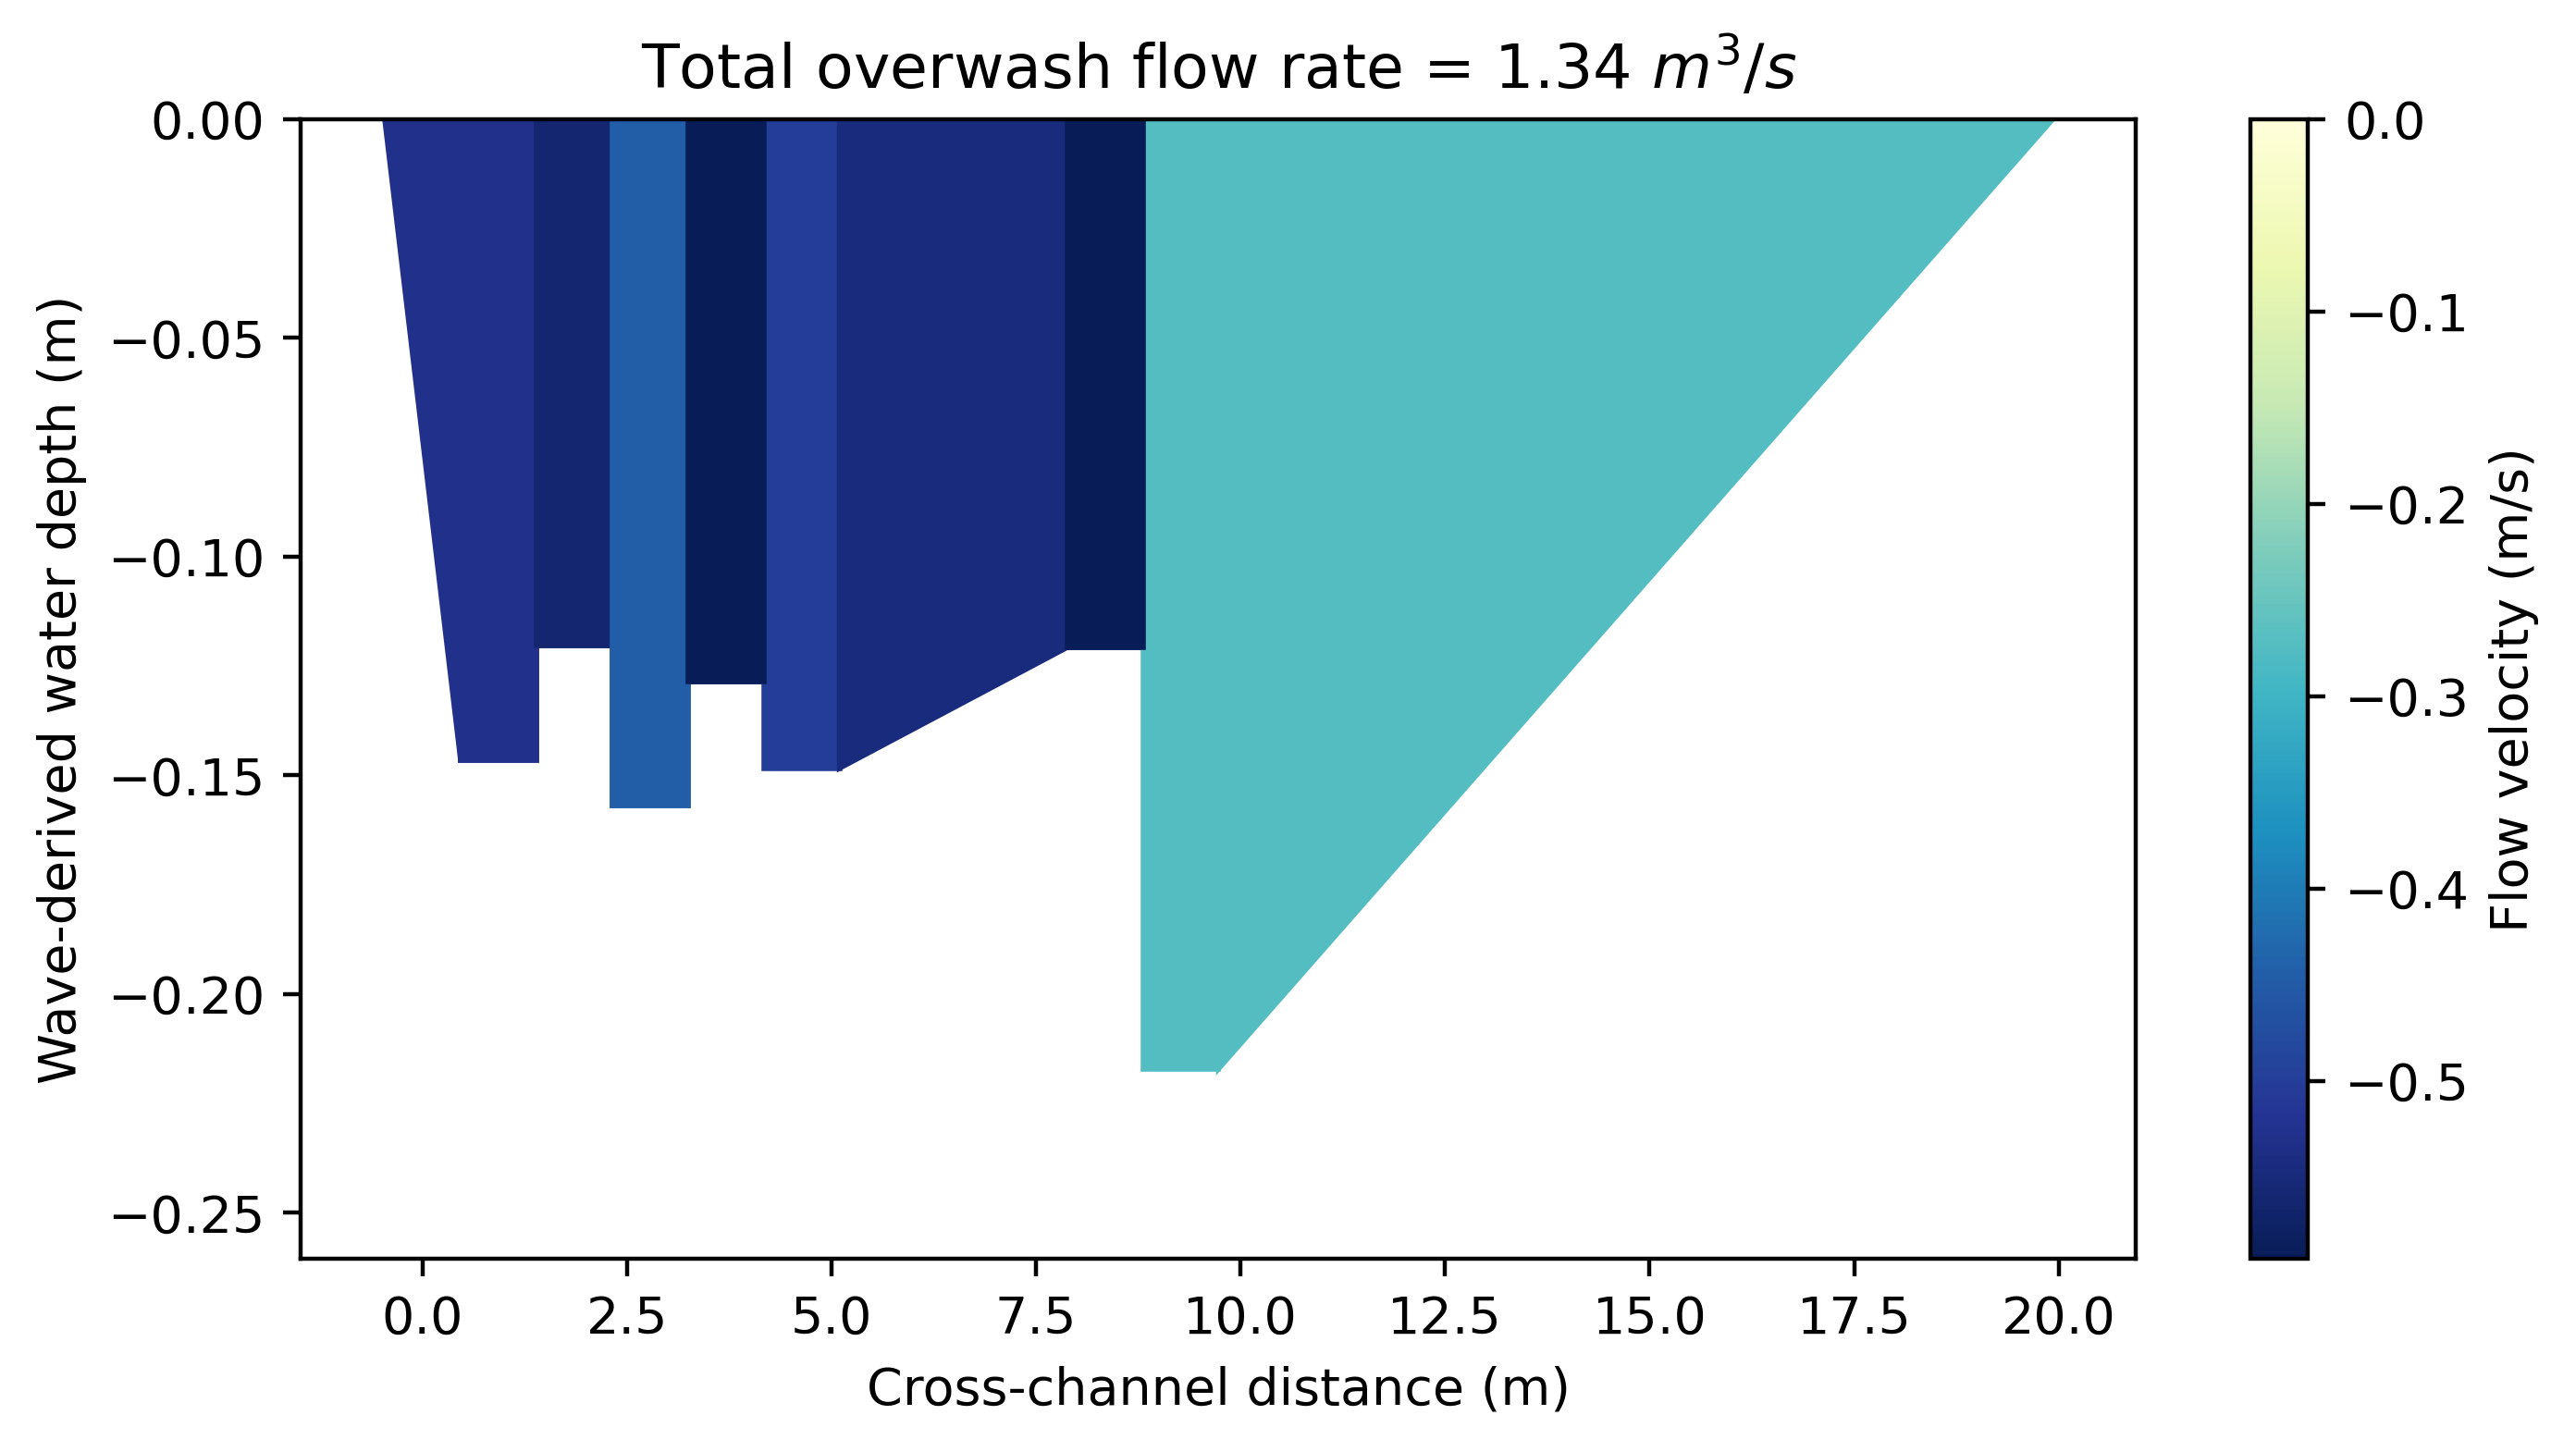

In [42]:
mean_depths = NaNStatistics.nanmean(depths, dims = 1)[:]
mean_velocities = NaNStatistics.nanmean(velocities, dims = 1)[:]

results = [normal_component(true_lines_xy[i], ref_start_xy, ref_end_xy, mean_velocities[i])
    for i in 1:length(true_lines_xy)]

mean_velocities = first.(results)

cmap = plt.cm.YlGnBu_r
valid_vels = mean_velocities[.!isnan.(mean_velocities)]
norm_colors = plt.matplotlib.colors.Normalize(vmin=minimum(valid_vels), vmax=0)

fig, ax = plt.subplots(figsize=(8, 4), dpi = 400)

dx = step(distances)
physical_x = (indices .- 1) .* dx

total_discharge = 0.0  # sum of all bins
valid_idx = findall(x -> !isnan(x), mean_depths)

# Draw rectangles for valid bins & calculate discharge
for (i, x) in enumerate(physical_x)
    z = mean_depths[i]
    v = mean_velocities[i]
    if !isnan(z) && !isnan(v)
        color = cmap(norm_colors(v))
        ax.fill([x-dx/2, x+dx/2, x+dx/2, x-dx/2],
                [0, 0, -z, -z], color=color, edgecolor="k")
        total_discharge += dx * z * v
    end
end

# Handle triangular edges
# left edge
first_valid = findfirst(x -> !isnan(x), mean_depths)
if first_valid !== nothing && first_valid > 1
    z = mean_depths[first_valid]
    v = mean_velocities[first_valid]
    color = cmap(norm_colors(v))
    base = physical_x[first_valid] - physical_x[1]
    ax.fill([physical_x[1]-dx/2, physical_x[first_valid]-dx/2, physical_x[first_valid]-dx/2],
            [0, 0, -z], color=color, edgecolor="k")
    total_discharge += 0.5 * base * z * v
end

for k in 1:(length(valid_idx)-1)
    i = valid_idx[k]
    j = valid_idx[k+1]
    z_i, z_j = mean_depths[i], mean_depths[j]
    v_i, v_j = mean_velocities[i], mean_velocities[j]

    if j == i + 1
        # Adjacent bins -> rectangle
        ax.fill([physical_x[i]-dx/2, physical_x[i]+dx/2, physical_x[i]+dx/2, physical_x[i]-dx/2],
                [0,0,-z_i,-z_i], color=cmap(norm_colors(v_i)), edgecolor="k")
        total_discharge += dx * z_i * v_i
    else
        # Gap exists -> trapezoid connecting depths
        x_left = physical_x[i] + dx/2   # right edge of left valid bin
        x_right = physical_x[j] - dx/2  # left edge of right valid bin
        ax.fill([x_left, x_right, x_right, x_left],
                [0,0,-z_j,-z_i], color=cmap(norm_colors((v_i+v_j)/2)), edgecolor="k")
        base = x_right - x_left
        area = 0.5 * (z_i + z_j) * base
        total_discharge += area * ((v_i+v_j)/2)
    end
end

# right edge
last_valid  = findlast(x -> !isnan(x), mean_depths)
if last_valid !== nothing && last_valid < n_verticals
    z = mean_depths[last_valid]
    v = mean_velocities[last_valid]
    color = cmap(norm_colors(v))
    base = physical_x[end] - physical_x[last_valid]
    ax.fill([physical_x[last_valid]+dx/2, physical_x[end]+dx/2, physical_x[last_valid]+dx/2],
            [0, 0, -z], color=color, edgecolor="k")
    total_discharge += 0.5 * base * z * v
end

# Find all valid indices

ax.set_xlabel("Cross-channel distance (m)")
ax.set_ylabel("Wave-derived water depth (m)")
ax.set_title("Total overwash flow rate = $(-round(total_discharge, digits = 2)) $(LaTeXStrings.L"m^3/s")")
max_depth = maximum(mean_depths[.!isnan.(mean_depths)])
ax.set_ylim(-max_depth*1.2, 0)
fig.colorbar(plt.cm.ScalarMappable(norm=norm_colors, cmap=cmap), ax=ax, 
    label="Flow velocity (m/s)")

# plt.scatter(gcp_distances, -gcp_depths, zorder = 2) # compare projected GCP depths - not 1:1 (uphill of STIV)

plt.gcf()

In [13]:
# SC4_bot_z = SC_bots_xyz_8_1[4,4] # WSE
# interpolated_grid_spacing=10
# RectParams = IRQIV.ImageRectification.calculate_image_rectification(Camera, χcalculated_SC_8_1,
#     SC4_bot_z; 
#     interpolated_grid_spacing,
#     ROI_polygon_pixels = [
#         # (784, 275),
#         (784,400),
#         # (0,190),
#         (0,300),
#         (0,370),
#         (784,530)
#     ])

In [123]:
STIV_row = 20

# STIV
plt.close("all")
fig = plt.figure(figsize=(7,5))
ax = plt.gca()
# Select IR image file:
FLIR_filename = raw"/Volumes/ETH_4TB/DH_IR/Rec-HRE_2023_-003723-__TIME__.ats"
# Load IR images (from Sutter Slough):
nfiles = 300
IRimages = LoadATSImageSequence(FLIR_filename, nfiles, 2023)
# rectified_image = RectParams(IRimages[1])[far_field_exclude:end,:]

STIV_fig = zeros(size(rectified_image)[2], length(IRimages)).*NaN


nticks = 6
# tick_int = STIV_yticks/(nticks-1)
# tick_labels = 
###############################################################################

for i in 1:length(IRimages)
    rectified_image = RectParams(IRimages[i])[far_field_exclude:end,:]
    STIV_fig[:,i] = rectified_image[STIV_row,:]

    ###############################################################################
    # plt.show()
end

function remove_nans(row)
    return filter(!isnan, row)
end
STIV_real = hcat(map(remove_nans, eachcol(STIV_fig))...)
nanmask_col = .!isnan.(STIV_fig[:,1])

# Create yticks - spatial
STIV_y_coords = RectParams.UTMxi'[STIV_row+far_field_exclude,:][nanmask_col] # Get UTM coordinates in x for STIV y-axis label
total_ticks = size(STIV_real)[1]
total_distance_m = STIV_y_coords[end] - STIV_y_coords[1]
tick_increment = total_distance_m/total_ticks * 20
yticks_m = 0:tick_increment:(total_distance_m - 1e-10)  # Adjusted to avoid floating-point precision issues
yticks_m = round.(yticks_m, digits=1)
yticks_ind = round.(Int, yticks_m ./ (total_distance_m / (total_ticks - 1)))

# Create xticks - temporal
total_axis_length = size(STIV_real)[2]
dt = 1/IRimages.Metadata.Estimatedfps
num_labels = 10
xticks_s = range(0, stop=(total_axis_length - 1) * dt, length=num_labels)
xticks_s = round.(xticks_s, digits= 2)
xticks_ind = round.(Int, xticks_s / dt) .+ 1

# STIV segments:
wave_segs = [[(0,46), (80,129)], [(51,0), (169,129)], [(203.6,66.9), (258,129)]]
# bulk_segs = [[(51.4,57.1), (116.2,88)], [(85.5,30.5), (136.1,51.7)], [(177,41), (299,86)]]
bulk_segs = [[(42.3,46.4), (184.2,104.3)],[(114.8,42.7),(299,124.7)],[(177,39), (299,84)]]

plt.close("all")
fig = plt.figure(figsize=(9,5))
ax = plt.gca()
ax.imshow(STIV_real)
i=1
for segment in wave_segs
    x_vals, y_vals = zip(segment...)
    if i == 1
        plt.plot(x_vals, y_vals, color="red", linewidth=2, linestyle="--", label="Wave celerity")
    else
        plt.plot(x_vals, y_vals, color="red", linewidth=2, linestyle="--")
    end
    i +=1
end
i=1
for segment in bulk_segs
    x_vals, y_vals = zip(segment...)
    if i == 1
        plt.plot(x_vals, y_vals, color="white", linewidth=2, linestyle="-.", label="Bulk velocity")
    else
        plt.plot(x_vals, y_vals, color="white", linewidth=2, linestyle="-.")
    end
    i +=1
end
plt.yticks(yticks_ind, string.(yticks_m, " m"))
plt.xticks(xticks_ind, string.(xticks_s, " s"))
plt.xlabel("Time (s)")
plt.ylabel("Distance (m)")
plt.legend()
plt.show()

# Calculate slope of defined segments
function calculate_slope(point1, point2)
    x1, y1 = point1
    x2, y2 = point2
    
    if x2 == x1
        return Inf  # Vertical line, undefined slope
    else
        return (y2 - y1) / (x2 - x1)
    end
end
dx = total_distance_m/total_ticks
dt = 0.05

wave_vels = zeros(length(wave_segs))
bulk_vels = zeros(length(bulk_segs))

for (i, segment) in enumerate(wave_segs)
    wave_vels[i] = calculate_slope(segment[1], segment[2])*(dx/dt)
end

for (i, segment) in enumerate(bulk_segs)
    bulk_vels[i] = calculate_slope(segment[1], segment[2])*(dx/dt)
end

wave_cs = wave_vels.-bulk_vels
wave_hs = (wave_cs.^2)/9.81
wave_cs_mean = mean(wave_vels)-mean(bulk_vels)
wave_hs_mean = wave_cs_mean^2/9.81



UndefVarError: UndefVarError: `rectified_image` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [122]:
clip_ind = 40 # Isolate portion of line where waves are breaking
STIV_real = STIV_real[clip_ind:end,:]
STIV_real .-= mean(STIV_real)
STIV_points = distribute_points_centered(10, size(STIV_real))

plt.close("all")
# Create the plot
fig, ax = plt.subplots()

# Plot the image using imshow
ax.imshow(STIV_real, origin="lower", )

theta = LinRange(0, 2 * π, 100)

rows = size(STIV_real)[1]
cols = size(STIV_real)[2]

total_ticks = size(STIV_real)[1]
total_distance_m = STIV_y_coords[end] - STIV_y_coords[clip_ind]
tick_increment = total_distance_m/total_ticks * 20
yticks_m = 0:tick_increment:(total_distance_m - 1e-10)  # Adjusted to avoid floating-point precision issues
yticks_m = round.(yticks_m, digits=1)
yticks_ind = round.(Int, yticks_m ./ (total_distance_m / (total_ticks - 1)))

# Plot circles with diameters equal to the vertical size of the image (rows)
for coords in STIV_points
    x = coords[2]
    y = coords[1]
    # Parametric equations for a circle
    x_circle = x .+ (rows / 2) * cos.(theta)
    y_circle = y .+ (rows / 2) * sin.(theta)
    ax.plot(x_circle, y_circle, color="red", lw=1)
end

plt.yticks(yticks_ind, string.(yticks_m, " m"))
plt.xticks(xticks_ind, string.(xticks_s, " s"))

# Set plot limits
# ax.set_xlim(0, cols)
# ax.set_ylim(0, rows)

# Equal aspect ratio for correct circle shape
# ax.set_aspect('equal', adjustable='box')

# Show the plot
plt.gcf()

UndefVarError: UndefVarError: `STIV_real` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [121]:
STIV_peaks, STIV_mids = find_peaks_and_midpoints(STIV_real, 
    7, 5, 10)

plt.figure()
plt.imshow(STIV_real)
h1 = plt.scatter(last.(STIV_peaks), first.(STIV_peaks),
    color = "red", label = "Max intensity")
h2 = plt.scatter(last.(STIV_mids), first.(STIV_mids),
    color = "orange", label = "Mid intensity")
plt.yticks(yticks_ind, string.(yticks_m, " m"))
plt.xticks(xticks_ind, string.(xticks_s, " s"))
plt.legend(handles = [h1, h2])
plt.gcf()

# plt.figure()
# plt.hist(STIV_real[ceil(Int, size(STIV_real, 1) / 2),:], bins = 25)
# plt.xlabel("Pixel intensity (mean subtracted)")
# plt.ylabel("Counts in center row of S-T diagram")
# plt.gcf()


UndefVarError: UndefVarError: `STIV_real` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
# Looping through each location

slope_vec_wave = []
slope_vec_bulk = []
x_inds_vec = []

plt.close("all")

for coords in STIV_mids
    xOrigin = coords[2]
    yOrigin = coords[1]
    STIV_sq_rows, STIV_sq_cols = max_centered_array_size(xOrigin, yOrigin, size(STIV_real))
    y = STIV_real[STIV_sq_rows, STIV_sq_cols]
    center = Int(ceil(size(y)[1]/2)) # round() rounds down if .508
    x = 1:size(y)[1]
    xOriginCropped = center
    yOriginCropped = center
    radius = center-1

    # Compute the 2D Fourier transform and the power spectrum
    Rxy = FFTW.ifft(abs.(FFTW.fft(y)).^2) ./ length(y)
    Rxy = FFTW.fftshift(abs.(Rxy)) # Seems important - shifts zero-frequency component to center of spectrum

    # Define angles and compute coordinates for the circle mask
    # -966-70    
    θ_c = range(1, stop = 360, length = 360)
    xc = radius * cosd.(θ_c) .+ xOriginCropped
    yc = radius * sind.(θ_c) .+ yOriginCropped

    # Create a circular mask
    circ_mask = polygons_to_mask([hcat(xc, yc)], xOriginCropped+radius, yOriginCropped+radius)
    circ_nan = ones(Float64, size(circ_mask))
    circ_nan[.!circ_mask] .= NaN

    θ = zeros(Float64, length(x), length(x))
    ρ = zeros(Float64, length(x), length(x))
    Tx = zeros(Float64, length(x), length(x))
    Ty = zeros(Float64, length(x), length(x))
    M = 15  # "coefficient of intensification"

    # Calculate theta and ρ for each pixel within the mask - polar transform
    for i in 1:length(x)
        for j in 1:length(x)
            if circ_mask[i, j]
                Tx[i,j] = xOriginCropped - j
                Ty[i,j] = yOriginCropped - i
                θ[i,j] = atand(Ty[i,j] / Tx[i, j]) # -90 to 90
                ρ[i,j] = M * log(sqrt(Tx[i,j]^2 + Ty[i,j]^2)) 
            end
        end
    end

    # Apply the circular mask to Rxy
    Rxy_pol_norm = Rxy .* circ_nan ./ Rxy[yOriginCropped, xOriginCropped]

    ρ = ρ .* circ_nan
    θ = θ .* circ_nan

    # # Aggregate by polar coordinates
    AngleIncrement = 1
    AngleVec = [1:1*AngleIncrement:180]
    inds_vec = zeros(Int, length(AngleVec))
    μ = zeros(Float64, length(AngleVec))
    ρ_max = M*log(minimum([maximum(filter(!isnan,Tx)),maximum(filter(!isnan,Ty))]))

    for i in 1:length(AngleVec)
        a = i-90 # Convert index back to angle of theta
        inds = findall(θ -> round(θ) == a, θ[:])
        inds_vec[i] = length(inds)
        Rxy_int = sum(Rxy_pol_norm[inds])/inds_vec[i] # Normalize by # of pixels within each degree - varies widely!
        # Rxy_int = sum(Rxy_pol_norm[inds])^2/inds_vec[i] # Flight C
        μ[i] = (1/ρ_max)*Rxy_int
    end

    moving_avg_n = 5 # Can set to 1 for raw, Fujita uses 5 point fitted curve
    φ_range_wave = 35:90  # Wave range
    μ_subset_wave = centered_moving_average(μ, moving_avg_n)[φ_range_wave .+ 90]  # Extract only relevant values
    φ_wave = φ_range_wave[argmax(μ_subset_wave)]
    φ_range_bulk = 1:34#15:30
    μ_subset_bulk = centered_moving_average(μ, moving_avg_n)[φ_range_bulk .+ 90]
    φ_bulk = φ_range_bulk[argmax(μ_subset_bulk)]
    # φ = argmax(μ) - 90

    # if φ == 90 || φ == 0
    #     continue
    # end

    push!(slope_vec_wave, φ_wave)
    push!(slope_vec_bulk, φ_bulk)
    push!(x_inds_vec, (STIV_sq_cols[1], STIV_sq_cols[end]))
    
    # plt.close("all")
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # First subplot: μ vs. angle
    axes[1].plot(AngleVec.-90, centered_moving_average(μ, moving_avg_n))
    # axes[1].set_title("Fujita method μ; φ = $φ °")
    axes[1].set_xlabel("Angle (degrees)")
    axes[1].set_ylabel("Normalized autocorrelation")
    axes[1].axvline(φ_wave, color = "red", label = "Wave celerity")
    axes[1].axvline(φ_bulk, color = "orange", label = "Bulk velocity")
    axes[1].legend()

    # Second subplot: Rxy image with detected angle
    plot_angle_wave = φ_wave  # Adjust for image coordinate system
    xEdge_wave = xOriginCropped + radius * cosd(plot_angle_wave)
    yEdge_wave = yOriginCropped + radius * sind(plot_angle_wave)

    plot_angle_bulk = φ_bulk  # Adjust for image coordinate system
    xEdge_bulk = xOriginCropped + radius * cosd(plot_angle_bulk)
    yEdge_bulk = yOriginCropped + radius * sind(plot_angle_bulk)

    # im = axes[2].imshow(Rxy_pol_norm, cmap="viridis", origin = "lower")
    im = axes[2].imshow(y, cmap="viridis", origin = "lower")
    axes[2].plot([xOriginCropped, xEdge_wave], [yOriginCropped, yEdge_wave], color="red", lw=2)
    axes[2].plot([xOriginCropped, xEdge_bulk], [yOriginCropped, yEdge_bulk], color="orange", lw=2)
    fig.colorbar(im, ax=axes[2], label="Intensity")
    axes[2].set_title("Detected angle on STIV diagram")
    axes[2].set_xlabel("Pixels")
    axes[2].set_ylabel("Pixels")
    plt.yticks(yticks_ind, string.(yticks_m, " m"))
    plt.xlabel("Time (s)")
    plt.ylabel("Distance (m)")

    plt.tight_layout()
end

plt.show()


UndefVarError: UndefVarError: `STIV_mids` not defined in `Main`
Suggestion: check for spelling errors or missing imports.